[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E4_Many_To_Many_Demand.ipynb)

# Many-to-Many on the Demand Series
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Two ways an RNN can put out more than one number:

- **(a) Two targets at once** - next-hour demand *and* next-hour temperature from one model (`Dense(2)`), borrowing strength across both.
- **(b) Multi-step ahead** - the next **24 hours** of demand from the past week (`Dense(24)`), with error plotted by horizon against the seasonal-naive forecast. This is the forecast the dispatch desk actually wants.

*Energy-track version of the two BDL many-to-many notebooks (dew point + pressure; temperature +1h).*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 15B — Many-to-many: two targets at once, then 24 hours ahead
- (a) Two targets: put BOTH targets on the right, chop from the right with n_targets=2, Dense(2, linear). One model, two MAEs - in their own units after inverse_transform.
- (b) Multi-step: past week (168) -> next 24 hours, Dense(24). The tensor is (samples, 168, 8) -> (samples, 24).
- The plot that matters: MAE by horizon. Hour 1 is nearly free; hour 24 is the honest number. The fair baseline a day ahead is seasonal naive (~227), not persistence.
- Show one day-ahead forecast against reality - the model gets the shape, misses the peak height.
- Close on save/reload and the on-your-own: a holiday flag, GRU swap, test on 2020 (distribution shift).
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## (a) Two targets at once: demand *and* temperature

Move both targets to the right-hand side. `split_sequences_multi` takes the last `n_targets` columns at the next step as `y`; the inputs keep every column, so each target sees its own past.

In [3]:
cols2 = ["BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "BDL_tmpf", "Demand"]   # two targets LAST
tr2, te2 = train[cols2], test[cols2]
sc2   = MinMaxScaler().fit(tr2)
sc_t  = MinMaxScaler().fit(tr2[["BDL_tmpf", "Demand"]])   # target-only scaler to get real units back

def split_sequences_multi(seqs, n_steps, n_targets):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -n_targets:])
    return np.array(X), np.array(y)

n_steps = 24
X2_tr, y2_tr = split_sequences_multi(sc2.transform(tr2), n_steps, 2)
X2_te, y2_te = split_sequences_multi(sc2.transform(te2), n_steps, 2)
print("X:", X2_tr.shape, "| y:", y2_tr.shape, "-> two targets per sample")

X: (8736, 24, 8) | y: (8736, 2) -> two targets per sample


In [4]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

two = Sequential([LSTM(32, input_shape=(n_steps, X2_tr.shape[2])), Dense(2)])   # Dense(2, linear): one number per target
two.compile(optimizer="adam", loss="mse", metrics=["mae"])
two.summary()
two.fit(X2_tr, y2_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)

pred2 = sc_t.inverse_transform(two.predict(X2_te, verbose=0)); true2 = sc_t.inverse_transform(y2_te)
print(f"temperature MAE: {mean_absolute_error(true2[:, 0], pred2[:, 0]):.2f} F   |   demand MAE: {mean_absolute_error(true2[:, 1], pred2[:, 1]):.1f} MW")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314 (20.76 KB)

 Trainable params: 5,314 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


temperature MAE: 1.41 F   |   demand MAE: 50.8 MW


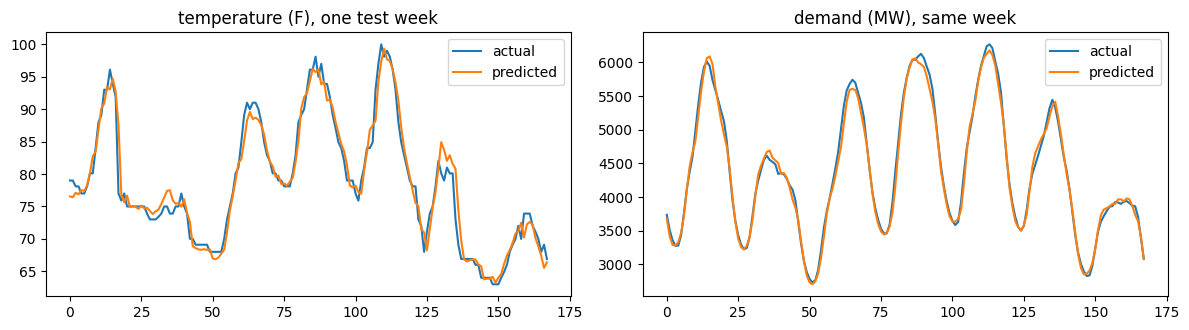

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4)); i0 = 24*7*28; sl = slice(i0, i0+24*7)
ax[0].plot(true2[sl, 0], label="actual"); ax[0].plot(pred2[sl, 0], label="predicted"); ax[0].set_title("temperature (F), one test week"); ax[0].legend()
ax[1].plot(true2[sl, 1], label="actual"); ax[1].plot(pred2[sl, 1], label="predicted"); ax[1].set_title("demand (MW), same week"); ax[1].legend()
plt.tight_layout(); plt.show()

## (b) Multi-step: the next 24 hours of demand

One target, 24 steps. From the past **week**, predict tomorrow's 24 hourly values at once with `Dense(24)`.

In [6]:
sc   = MinMaxScaler().fit(train); sc_y = MinMaxScaler().fit(train[["Demand"]])
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_multistep(seqs, n_in, n_out):
    X, y = [], []
    for i in range(len(seqs) - n_in - n_out + 1):
        X.append(seqs[i:i+n_in, :]); y.append(seqs[i+n_in:i+n_in+n_out, -1])
    return np.array(X), np.array(y)

n_in, n_out = 24*7, 24
Xs_tr, ys_tr = split_multistep(tr_s, n_in, n_out)
Xs_te, ys_te = split_multistep(te_s, n_in, n_out)
print("multi-step tensors:", Xs_tr.shape, "->", ys_tr.shape)

step = Sequential([LSTM(64, input_shape=(n_in, Xs_tr.shape[2])), Dense(n_out)])
step.compile(optimizer="adam", loss="mse", metrics=["mae"])
step.summary()
step.fit(Xs_tr, ys_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

multi-step tensors: (8569, 168, 8) -> (8569, 24)


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,248 (79.09 KB)

 Trainable params: 20,248 (79.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 14:22 8s/step - loss: 0.1433 - mae: 0.3158

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.1285 - mae: 0.2990

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.1226 - mae: 0.2908

  4/108 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.1205 - mae: 0.2857

  5/108 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.1120 - mae: 0.2733

  6/108 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - loss: 0.1081 - mae: 0.2670

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.1023 - mae: 0.2584

  8/108 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0979 - mae: 0.2511

  9/108 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0931 - mae: 0.2433

 10/108 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0889 - mae: 0.2364

 11/108 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0846 - mae: 0.2293

 12/108 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0810 - mae: 0.2235

 13/108 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0783 - mae: 0.2188

 14/108 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0756 - mae: 0.2141

 15/108 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0730 - mae: 0.2096

 16/108 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0705 - mae: 0.2057

 17/108 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0683 - mae: 0.2019

 18/108 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0662 - mae: 0.1986

 19/108 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0643 - mae: 0.1952

 20/108 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0625 - mae: 0.1923

 21/108 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0609 - mae: 0.1895

 22/108 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0593 - mae: 0.1866

 23/108 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0579 - mae: 0.1842 

 24/108 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss: 0.0566 - mae: 0.1819

 25/108 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0553 - mae: 0.1794

 26/108 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0545 - mae: 0.1781

 27/108 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0536 - mae: 0.1764

 28/108 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0529 - mae: 0.1751

 29/108 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0520 - mae: 0.1734

 30/108 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0511 - mae: 0.1715

 31/108 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0503 - mae: 0.1701

 32/108 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0495 - mae: 0.1686

 33/108 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0487 - mae: 0.1670

 34/108 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0480 - mae: 0.1658

 35/108 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 0.0474 - mae: 0.1645

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 0.0467 - mae: 0.1632

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0461 - mae: 0.1620

 38/108 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0454 - mae: 0.1607

 39/108 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0448 - mae: 0.1595

 40/108 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0442 - mae: 0.1581

 41/108 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0436 - mae: 0.1571

 42/108 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0431 - mae: 0.1560

 43/108 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0426 - mae: 0.1550

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0421 - mae: 0.1542

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0417 - mae: 0.1533

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0413 - mae: 0.1524

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0408 - mae: 0.1515

 48/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0404 - mae: 0.1507

 49/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0400 - mae: 0.1498

 50/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0397 - mae: 0.1491

 51/108 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 0.0392 - mae: 0.1483

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0389 - mae: 0.1478

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0386 - mae: 0.1472

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0383 - mae: 0.1465

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0379 - mae: 0.1457

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0376 - mae: 0.1450

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0373 - mae: 0.1444

 58/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0369 - mae: 0.1436

 59/108 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0366 - mae: 0.1429

 60/108 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0363 - mae: 0.1424

 61/108 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0361 - mae: 0.1419

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0358 - mae: 0.1413

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0355 - mae: 0.1409

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0352 - mae: 0.1401

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0349 - mae: 0.1394

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0346 - mae: 0.1389

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0344 - mae: 0.1383

 68/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0342 - mae: 0.1379

 69/108 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0339 - mae: 0.1373

 70/108 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0336 - mae: 0.1368

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0333 - mae: 0.1362

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0331 - mae: 0.1356

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0328 - mae: 0.1350

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0326 - mae: 0.1344

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0323 - mae: 0.1338

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0321 - mae: 0.1333

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0318 - mae: 0.1327

 78/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0316 - mae: 0.1322

 79/108 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0314 - mae: 0.1316

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0311 - mae: 0.1311

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0309 - mae: 0.1305

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0307 - mae: 0.1300

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0305 - mae: 0.1295

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0302 - mae: 0.1290

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0300 - mae: 0.1285

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0298 - mae: 0.1279

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0296 - mae: 0.1275

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0294 - mae: 0.1271

 89/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0292 - mae: 0.1265

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0290 - mae: 0.1260

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0288 - mae: 0.1255

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0286 - mae: 0.1250

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0284 - mae: 0.1245

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0282 - mae: 0.1241

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0280 - mae: 0.1236

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0279 - mae: 0.1232

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0277 - mae: 0.1227

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0275 - mae: 0.1222

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0273 - mae: 0.1217

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0271 - mae: 0.1213

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0269 - mae: 0.1208

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0268 - mae: 0.1204

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0266 - mae: 0.1199

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0264 - mae: 0.1195

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0262 - mae: 0.1189

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0261 - mae: 0.1185

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0259 - mae: 0.1180

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0259 - mae: 0.1180

108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - loss: 0.0259 - mae: 0.1180 - val_loss: 0.0056 - val_mae: 0.0603


Epoch 2/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - loss: 0.0086 - mae: 0.0742

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0079 - mae: 0.0712 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0080 - mae: 0.0716 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0083 - mae: 0.0722

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0082 - mae: 0.0717

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0083 - mae: 0.0720

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0082 - mae: 0.0716

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0081 - mae: 0.0715

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0082 - mae: 0.0716

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0081 - mae: 0.0715

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0081 - mae: 0.0714

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0083 - mae: 0.0718

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0083 - mae: 0.0717

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0085 - mae: 0.0724

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0085 - mae: 0.0722

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0085 - mae: 0.0721

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0084 - mae: 0.0718

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0084 - mae: 0.0716

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0083 - mae: 0.0714

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0084 - mae: 0.0717

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0083 - mae: 0.0716

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0083 - mae: 0.0713

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0082 - mae: 0.0711

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0082 - mae: 0.0708

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0704

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0704

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0703

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0704

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0704

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0081 - mae: 0.0703

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0080 - mae: 0.0702

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0080 - mae: 0.0700

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0080 - mae: 0.0699

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0079 - mae: 0.0697

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0079 - mae: 0.0695

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0079 - mae: 0.0694

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0079 - mae: 0.0693

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0078 - mae: 0.0692

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0078 - mae: 0.0690

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0078 - mae: 0.0689

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0077 - mae: 0.0687

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0077 - mae: 0.0687

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0077 - mae: 0.0685

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0077 - mae: 0.0685

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0076 - mae: 0.0683

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0076 - mae: 0.0683

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0076 - mae: 0.0682

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0076 - mae: 0.0680

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0076 - mae: 0.0679

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0075 - mae: 0.0679

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0075 - mae: 0.0677

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0075 - mae: 0.0678

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0075 - mae: 0.0677

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0075 - mae: 0.0676

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0075 - mae: 0.0674

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0074 - mae: 0.0673

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0074 - mae: 0.0672

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0074 - mae: 0.0670

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0669

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0668

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0667

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0666

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0666

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0073 - mae: 0.0665

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0072 - mae: 0.0664

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0072 - mae: 0.0663

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0072 - mae: 0.0662

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0663

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0663

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0662

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0662

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0661

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0072 - mae: 0.0661

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0072 - mae: 0.0660

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0072 - mae: 0.0660

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0072 - mae: 0.0660

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0071 - mae: 0.0659

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0071 - mae: 0.0659

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0071 - mae: 0.0658

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0659

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0658

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0658

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0657

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0658

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0658

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0657

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0071 - mae: 0.0657

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0658

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0657

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0657

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0657

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0657

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0071 - mae: 0.0656

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0071 - mae: 0.0656

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0656

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0071 - mae: 0.0655

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0071 - mae: 0.0654

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0071 - mae: 0.0654

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0653

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0654

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0653

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0652

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0651

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0651

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0650

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0070 - mae: 0.0649

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0069 - mae: 0.0649

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0069 - mae: 0.0649 - val_loss: 0.0043 - val_mae: 0.0531


Epoch 3/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16:17 9s/step - loss: 0.0057 - mae: 0.0595

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0054 - mae: 0.0583 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0054 - mae: 0.0586

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0055 - mae: 0.0587

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0056 - mae: 0.0591

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0056 - mae: 0.0590

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0057 - mae: 0.0595  

  8/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0056 - mae: 0.0593

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0057 - mae: 0.0597  

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0058 - mae: 0.0598

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0058 - mae: 0.0600 

 12/108 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0059 - mae: 0.0603

 13/108 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0059 - mae: 0.0603

 14/108 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0060 - mae: 0.0608

 15/108 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0060 - mae: 0.0607

 16/108 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0061 - mae: 0.0609

 17/108 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0060 - mae: 0.0607 

 18/108 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0061 - mae: 0.0608

 19/108 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0060 - mae: 0.0607

 20/108 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0061 - mae: 0.0612

 21/108 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0061 - mae: 0.0611

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 0.0061 - mae: 0.0611

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0061 - mae: 0.0609

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0061 - mae: 0.0608

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0061 - mae: 0.0606

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0061 - mae: 0.0607

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0060 - mae: 0.0606

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0061 - mae: 0.0606

 29/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0060 - mae: 0.0607

 30/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0060 - mae: 0.0607

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0060 - mae: 0.0606

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0060 - mae: 0.0606

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0060 - mae: 0.0606

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0060 - mae: 0.0605

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0060 - mae: 0.0604

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0060 - mae: 0.0603

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0060 - mae: 0.0604

 38/108 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0060 - mae: 0.0603

 39/108 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.0060 - mae: 0.0603

 40/108 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.0060 - mae: 0.0602

 41/108 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.0060 - mae: 0.0601

 42/108 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.0060 - mae: 0.0602

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0601

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 0.0059 - mae: 0.0601

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0601

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0601

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0601

 48/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0600

 49/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0600

 50/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0600

 51/108 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.0059 - mae: 0.0599

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0059 - mae: 0.0600

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0059 - mae: 0.0600

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0059 - mae: 0.0599

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0059 - mae: 0.0598

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0059 - mae: 0.0598

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0058 - mae: 0.0597

 58/108 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0058 - mae: 0.0596

 59/108 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0058 - mae: 0.0595

 60/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0058 - mae: 0.0594

 61/108 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0058 - mae: 0.0593

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0058 - mae: 0.0593

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0058 - mae: 0.0594

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0058 - mae: 0.0593

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0058 - mae: 0.0593

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0058 - mae: 0.0592

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0058 - mae: 0.0592

 68/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0058 - mae: 0.0593

 69/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0058 - mae: 0.0593

 70/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0058 - mae: 0.0593

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0593

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0593

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0593

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0593

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0592

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0058 - mae: 0.0592

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0592

 78/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0593

 79/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0058 - mae: 0.0592

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0593

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0058 - mae: 0.0594

 89/108 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0058 - mae: 0.0594

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.0058 - mae: 0.0594

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0593

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0058 - mae: 0.0594

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0593

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0594

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0593

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0593

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0593

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0592

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0591

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0058 - mae: 0.0591

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0057 - mae: 0.0591

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0057 - mae: 0.0591

108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - loss: 0.0057 - mae: 0.0591 - val_loss: 0.0039 - val_mae: 0.0512


Epoch 4/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 13:58 8s/step - loss: 0.0050 - mae: 0.0561

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0050 - mae: 0.0564 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0050 - mae: 0.0566

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0050 - mae: 0.0566 

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0051 - mae: 0.0567

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0051 - mae: 0.0565

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0052 - mae: 0.0570

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0051 - mae: 0.0567

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0052 - mae: 0.0570

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0053 - mae: 0.0572

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0053 - mae: 0.0575

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0054 - mae: 0.0578

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0054 - mae: 0.0577

 14/108 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0055 - mae: 0.0581

 15/108 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0055 - mae: 0.0580

 16/108 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0056 - mae: 0.0583

 17/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0055 - mae: 0.0580 

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0055 - mae: 0.0581

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0055 - mae: 0.0581

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0056 - mae: 0.0585

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0056 - mae: 0.0585

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0056 - mae: 0.0584

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0056 - mae: 0.0582

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0055 - mae: 0.0581

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0055 - mae: 0.0580

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0055 - mae: 0.0580

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0055 - mae: 0.0579

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0055 - mae: 0.0579

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0055 - mae: 0.0579

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0055 - mae: 0.0579

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0055 - mae: 0.0577

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0055 - mae: 0.0578

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0054 - mae: 0.0577

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0054 - mae: 0.0577

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0054 - mae: 0.0576

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0576

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0576

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0575

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0575

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0575

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0054 - mae: 0.0574

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0054 - mae: 0.0574

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0054 - mae: 0.0573

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0054 - mae: 0.0574

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0054 - mae: 0.0574

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0054 - mae: 0.0575

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0054 - mae: 0.0575

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0054 - mae: 0.0574

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0054 - mae: 0.0574

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0054 - mae: 0.0574

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0054 - mae: 0.0573

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0054 - mae: 0.0574

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0054 - mae: 0.0574

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0054 - mae: 0.0574

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0054 - mae: 0.0573

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0054 - mae: 0.0573

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0054 - mae: 0.0572

 58/108 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0053 - mae: 0.0571

 59/108 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0053 - mae: 0.0570

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0053 - mae: 0.0569

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0053 - mae: 0.0569

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0569

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0569

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0053 - mae: 0.0569

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0568

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0568

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0568

 68/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0568

 69/108 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0053 - mae: 0.0569

 70/108 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0053 - mae: 0.0569

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0569

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0569

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 78/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0569

 79/108 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0053 - mae: 0.0568

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0053 - mae: 0.0569

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0053 - mae: 0.0569

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0569

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0053 - mae: 0.0570

 89/108 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0054 - mae: 0.0570

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0054 - mae: 0.0570

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0054 - mae: 0.0570

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0054 - mae: 0.0570

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0053 - mae: 0.0570

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0054 - mae: 0.0570

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0053 - mae: 0.0570

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0053 - mae: 0.0570

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0053 - mae: 0.0569

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0053 - mae: 0.0570

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0569

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0570

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0569

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0569

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0569

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0569

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0053 - mae: 0.0568

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0053 - mae: 0.0568

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0053 - mae: 0.0568

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0053 - mae: 0.0568

108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0053 - mae: 0.0568 - val_loss: 0.0037 - val_mae: 0.0503


Epoch 5/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 13:48 8s/step - loss: 0.0046 - mae: 0.0538

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.0047 - mae: 0.0550

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.0048 - mae: 0.0555

  4/108 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.0048 - mae: 0.0553

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0048 - mae: 0.0553

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0048 - mae: 0.0552

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0049 - mae: 0.0558

  8/108 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0049 - mae: 0.0554

  9/108 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0050 - mae: 0.0556

 10/108 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0050 - mae: 0.0559

 11/108 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0051 - mae: 0.0562

 12/108 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0051 - mae: 0.0563

 13/108 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0051 - mae: 0.0562

 14/108 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0052 - mae: 0.0566

 15/108 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0052 - mae: 0.0564 

 16/108 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0053 - mae: 0.0566

 17/108 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0052 - mae: 0.0563

 18/108 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0052 - mae: 0.0564

 19/108 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0052 - mae: 0.0564

 20/108 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0053 - mae: 0.0569

 21/108 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0053 - mae: 0.0568

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0053 - mae: 0.0567

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0053 - mae: 0.0565

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0052 - mae: 0.0564

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0052 - mae: 0.0563

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0052 - mae: 0.0562

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0052 - mae: 0.0562

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0052 - mae: 0.0561

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0052 - mae: 0.0561

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0052 - mae: 0.0560

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0051 - mae: 0.0559 

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0051 - mae: 0.0560

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0051 - mae: 0.0559

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0051 - mae: 0.0558 

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0051 - mae: 0.0558

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0051 - mae: 0.0557

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0051 - mae: 0.0558

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0051 - mae: 0.0557

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0051 - mae: 0.0557

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0051 - mae: 0.0556 

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0051 - mae: 0.0556

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0556

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0555

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0556

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0555

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0556

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0051 - mae: 0.0556

 48/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0051 - mae: 0.0555

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0555

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0555

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0050 - mae: 0.0555

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0556

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0556

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0555

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0051 - mae: 0.0555

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0051 - mae: 0.0555

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0050 - mae: 0.0553

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0553

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0552

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0050 - mae: 0.0551 

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0050 - mae: 0.0550

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0050 - mae: 0.0550

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0050 - mae: 0.0551

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0550

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0550

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0550

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0050 - mae: 0.0549

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0050 - mae: 0.0550

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0050 - mae: 0.0550

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0050 - mae: 0.0550

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0050 - mae: 0.0550

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0050 - mae: 0.0550

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 78/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0050 - mae: 0.0550

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0551

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0550

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0050 - mae: 0.0551

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0050 - mae: 0.0551

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0050 - mae: 0.0552

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0050 - mae: 0.0551

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0050 - mae: 0.0552

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - mae: 0.0551

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - mae: 0.0552

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0050 - mae: 0.0551

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - mae: 0.0551

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - mae: 0.0551

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - mae: 0.0551

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0551

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0550

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0550

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0050 - mae: 0.0549

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0050 - mae: 0.0549

108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0050 - mae: 0.0549 - val_loss: 0.0034 - val_mae: 0.0482


Epoch 6/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 28s 270ms/step - loss: 0.0042 - mae: 0.0510

  2/108 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - loss: 0.0044 - mae: 0.0525

  3/108 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0045 - mae: 0.0536

  4/108 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0046 - mae: 0.0536

  5/108 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0046 - mae: 0.0536

  6/108 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - loss: 0.0046 - mae: 0.0534

  7/108 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0047 - mae: 0.0541

  8/108 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - loss: 0.0046 - mae: 0.0538

  9/108 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.0047 - mae: 0.0539

 10/108 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0048 - mae: 0.0542

 11/108 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0049 - mae: 0.0545

 12/108 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0049 - mae: 0.0546

 13/108 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0049 - mae: 0.0546

 14/108 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0049 - mae: 0.0549

 15/108 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0049 - mae: 0.0547

 16/108 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0050 - mae: 0.0549

 17/108 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0049 - mae: 0.0547

 18/108 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0049 - mae: 0.0548 

 19/108 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0049 - mae: 0.0547

 20/108 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0050 - mae: 0.0552

 21/108 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0050 - mae: 0.0551

 22/108 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0050 - mae: 0.0550

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 0.0050 - mae: 0.0548

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0050 - mae: 0.0547

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0049 - mae: 0.0545

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0049 - mae: 0.0545

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0049 - mae: 0.0544

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0049 - mae: 0.0543

 29/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0049 - mae: 0.0543

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0049 - mae: 0.0542

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0048 - mae: 0.0541

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0048 - mae: 0.0541

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0048 - mae: 0.0540

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0048 - mae: 0.0540

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0048 - mae: 0.0540

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0048 - mae: 0.0539

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0048 - mae: 0.0540

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0539 

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0539

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0538

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0538

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0538

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0048 - mae: 0.0537

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0048 - mae: 0.0538

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0048 - mae: 0.0537

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0048 - mae: 0.0538

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0538

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0536

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0048 - mae: 0.0537

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0048 - mae: 0.0536

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0048 - mae: 0.0536

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0535

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0535

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0533

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0533

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0532

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0532

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0533

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0532

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0047 - mae: 0.0531

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0047 - mae: 0.0531

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0531

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0531

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0532

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0531

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0047 - mae: 0.0531

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0047 - mae: 0.0531

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0532

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0532

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - mae: 0.0531

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0047 - mae: 0.0531

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0047 - mae: 0.0532

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0047 - mae: 0.0532

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0047 - mae: 0.0531

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0047 - mae: 0.0532

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0532

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0532

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0532

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0532

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0532

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0531

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0531

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0530

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0530

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0047 - mae: 0.0530

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0047 - mae: 0.0530 - val_loss: 0.0031 - val_mae: 0.0455


Epoch 7/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - loss: 0.0039 - mae: 0.0487

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0039 - mae: 0.0492 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0041 - mae: 0.0506 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0042 - mae: 0.0511

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0043 - mae: 0.0512

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0042 - mae: 0.0509

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0043 - mae: 0.0516

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0043 - mae: 0.0514

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0044 - mae: 0.0517

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0045 - mae: 0.0520

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0045 - mae: 0.0523

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0046 - mae: 0.0524

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0045 - mae: 0.0524

 14/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0046 - mae: 0.0528

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0046 - mae: 0.0526

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0047 - mae: 0.0529

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0046 - mae: 0.0527

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0047 - mae: 0.0528

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0046 - mae: 0.0528

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0047 - mae: 0.0532

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0047 - mae: 0.0531

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0047 - mae: 0.0530

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0047 - mae: 0.0528

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0047 - mae: 0.0526

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0046 - mae: 0.0525

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0046 - mae: 0.0524 

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0046 - mae: 0.0524

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0046 - mae: 0.0523

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0046 - mae: 0.0522

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0046 - mae: 0.0522

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0046 - mae: 0.0520

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0046 - mae: 0.0521

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0045 - mae: 0.0520

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0045 - mae: 0.0520

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0045 - mae: 0.0519

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0045 - mae: 0.0519

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0046 - mae: 0.0519

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0045 - mae: 0.0519

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0045 - mae: 0.0519

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0045 - mae: 0.0518

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0045 - mae: 0.0518

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0045 - mae: 0.0518

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0045 - mae: 0.0517

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0045 - mae: 0.0518

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0045 - mae: 0.0517

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0045 - mae: 0.0518

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0045 - mae: 0.0518

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0517

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0517

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0045 - mae: 0.0517

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0516 

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0045 - mae: 0.0518

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0045 - mae: 0.0518

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0518 

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0517

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0517

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0045 - mae: 0.0516

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0045 - mae: 0.0515

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0044 - mae: 0.0514

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0044 - mae: 0.0513

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0513

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0513

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0513

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0512

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0512

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0044 - mae: 0.0512

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0511

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0512

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0044 - mae: 0.0511

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0044 - mae: 0.0512

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0044 - mae: 0.0512

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0044 - mae: 0.0512

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0044 - mae: 0.0512

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0044 - mae: 0.0512

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0044 - mae: 0.0512

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0044 - mae: 0.0511

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0044 - mae: 0.0511

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0044 - mae: 0.0512

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0044 - mae: 0.0511

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0512

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0512

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0045 - mae: 0.0512

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0045 - mae: 0.0512

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0512

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0511

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0045 - mae: 0.0512

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0512

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0512

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0044 - mae: 0.0511

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0044 - mae: 0.0512

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0044 - mae: 0.0512

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0045 - mae: 0.0512

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0044 - mae: 0.0512

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0044 - mae: 0.0512

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0512

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0512

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0511

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0511

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0510

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0044 - mae: 0.0510

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0044 - mae: 0.0510 - val_loss: 0.0028 - val_mae: 0.0430


Epoch 8/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - loss: 0.0038 - mae: 0.0469

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0036 - mae: 0.0464  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0037 - mae: 0.0476

  4/108 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0039 - mae: 0.0484

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0040 - mae: 0.0487

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0039 - mae: 0.0483

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.0040 - mae: 0.0491

  8/108 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.0040 - mae: 0.0489

  9/108 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0041 - mae: 0.0495

 10/108 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0042 - mae: 0.0498

 11/108 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0042 - mae: 0.0500

 12/108 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0043 - mae: 0.0502

 13/108 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0043 - mae: 0.0502

 14/108 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0044 - mae: 0.0507

 15/108 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0044 - mae: 0.0507

 16/108 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0044 - mae: 0.0509

 17/108 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0044 - mae: 0.0507

 18/108 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0044 - mae: 0.0509 

 19/108 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0044 - mae: 0.0508

 20/108 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0045 - mae: 0.0512

 21/108 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0045 - mae: 0.0511

 22/108 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0044 - mae: 0.0510

 23/108 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0044 - mae: 0.0508

 24/108 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0044 - mae: 0.0507

 25/108 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0044 - mae: 0.0505

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0044 - mae: 0.0505

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.0044 - mae: 0.0504

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.0044 - mae: 0.0503

 29/108 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 0.0043 - mae: 0.0503

 30/108 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 0.0043 - mae: 0.0502

 31/108 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 0.0043 - mae: 0.0500

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0043 - mae: 0.0501

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0043 - mae: 0.0500

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0043 - mae: 0.0500

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0043 - mae: 0.0500

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0043 - mae: 0.0500

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0043 - mae: 0.0500

 38/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0043 - mae: 0.0499

 39/108 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0043 - mae: 0.0499

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0499

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0499

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0043 - mae: 0.0498

 48/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0042 - mae: 0.0497

 49/108 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0042 - mae: 0.0498

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0042 - mae: 0.0498

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0042 - mae: 0.0497

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0043 - mae: 0.0499

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0043 - mae: 0.0499

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0043 - mae: 0.0499

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0043 - mae: 0.0498

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0043 - mae: 0.0498

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0042 - mae: 0.0497

 58/108 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0042 - mae: 0.0496

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0495

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0042 - mae: 0.0494

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0042 - mae: 0.0494

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0042 - mae: 0.0494

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0495

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0494

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0493

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0493

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0493

 68/108 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0042 - mae: 0.0494

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0494

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0042 - mae: 0.0494

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0042 - mae: 0.0494

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0494

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0494

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0494

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0494

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0042 - mae: 0.0493

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0042 - mae: 0.0493

 78/108 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0042 - mae: 0.0494

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0042 - mae: 0.0494

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0494

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0494

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0042 - mae: 0.0494

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0494

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0493

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0493

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0494

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0493

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0042 - mae: 0.0494

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0494

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0494

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0494

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0494

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0493

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0042 - mae: 0.0494

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0042 - mae: 0.0493

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0042 - mae: 0.0494

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0042 - mae: 0.0493

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0042 - mae: 0.0494

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0494

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0494

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0494

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0494

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0494

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0493

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0493

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0042 - mae: 0.0493

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0042 - mae: 0.0492

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0042 - mae: 0.0492

108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0042 - mae: 0.0492 - val_loss: 0.0025 - val_mae: 0.0408


Epoch 9/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 27s 258ms/step - loss: 0.0036 - mae: 0.0453

  2/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0034 - mae: 0.0443

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0035 - mae: 0.0453 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0036 - mae: 0.0463 

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0037 - mae: 0.0467

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0036 - mae: 0.0463

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0038 - mae: 0.0471

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0038 - mae: 0.0470

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0039 - mae: 0.0476

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0040 - mae: 0.0480

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0040 - mae: 0.0482

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0040 - mae: 0.0484

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0040 - mae: 0.0484

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0041 - mae: 0.0489

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0042 - mae: 0.0490

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0042 - mae: 0.0493

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0042 - mae: 0.0490

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0042 - mae: 0.0492

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0042 - mae: 0.0491

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0042 - mae: 0.0495

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0042 - mae: 0.0494

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0042 - mae: 0.0493

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0042 - mae: 0.0491

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0042 - mae: 0.0490

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0042 - mae: 0.0489

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0042 - mae: 0.0488

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0041 - mae: 0.0487

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0487

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0486

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0485

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0484

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0484

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0483

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0041 - mae: 0.0483

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0483

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0041 - mae: 0.0483

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0483

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0040 - mae: 0.0481

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0041 - mae: 0.0482

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0040 - mae: 0.0481

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0041 - mae: 0.0482

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0041 - mae: 0.0482

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0040 - mae: 0.0481

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0040 - mae: 0.0481

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0040 - mae: 0.0481

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0040 - mae: 0.0481

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0041 - mae: 0.0483

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0041 - mae: 0.0483

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0041 - mae: 0.0482

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0040 - mae: 0.0482

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0482

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0481

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0480

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0479

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0478

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0478

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0478

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0479

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0478

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0040 - mae: 0.0478

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0040 - mae: 0.0477

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0040 - mae: 0.0478

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0040 - mae: 0.0478

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0040 - mae: 0.0478

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0040 - mae: 0.0478

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0040 - mae: 0.0478

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0040 - mae: 0.0478

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0040 - mae: 0.0478

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - mae: 0.0478

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0040 - mae: 0.0478

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0040 - mae: 0.0478

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0479

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0479

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0478

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0478

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0478

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0477

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0477

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0477

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0040 - mae: 0.0477

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0040 - mae: 0.0477 - val_loss: 0.0023 - val_mae: 0.0388


Epoch 10/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - loss: 0.0035 - mae: 0.0440

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0032 - mae: 0.0426  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0033 - mae: 0.0435

  4/108 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0034 - mae: 0.0446

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0035 - mae: 0.0450

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0034 - mae: 0.0446 

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0036 - mae: 0.0454

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0035 - mae: 0.0453

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0037 - mae: 0.0461

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0038 - mae: 0.0465

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0038 - mae: 0.0467

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0038 - mae: 0.0469

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0038 - mae: 0.0469

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0039 - mae: 0.0475

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0040 - mae: 0.0476

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0040 - mae: 0.0479

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0040 - mae: 0.0476

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0040 - mae: 0.0478

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0040 - mae: 0.0477

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0041 - mae: 0.0481

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0040 - mae: 0.0480

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0040 - mae: 0.0479

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0040 - mae: 0.0477

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0040 - mae: 0.0476

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0040 - mae: 0.0474

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0040 - mae: 0.0474

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0040 - mae: 0.0473

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0472

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0039 - mae: 0.0472

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0039 - mae: 0.0471

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0469

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0470

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0469

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0469

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0039 - mae: 0.0468

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0468

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0469

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0468

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0466

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0039 - mae: 0.0467

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0039 - mae: 0.0468

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0039 - mae: 0.0467

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0038 - mae: 0.0466

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0038 - mae: 0.0466

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0038 - mae: 0.0467

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0038 - mae: 0.0466

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0039 - mae: 0.0468

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0039 - mae: 0.0468

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0039 - mae: 0.0468

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0039 - mae: 0.0467

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0039 - mae: 0.0467

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0467

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0466

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0465

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0464

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0464

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0038 - mae: 0.0464

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0038 - mae: 0.0465

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0038 - mae: 0.0464

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0038 - mae: 0.0463

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0038 - mae: 0.0463

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0038 - mae: 0.0464

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0038 - mae: 0.0464

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0464

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0465

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0465

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0464

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0464

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0464

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0038 - mae: 0.0464

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0038 - mae: 0.0464

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0038 - mae: 0.0464

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0038 - mae: 0.0464

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0038 - mae: 0.0464

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0038 - mae: 0.0464

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0038 - mae: 0.0464

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0464

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0464

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0465

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0465

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0464

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0464

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0464

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0463

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0463

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0038 - mae: 0.0463

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0038 - mae: 0.0463 - val_loss: 0.0021 - val_mae: 0.0370


Epoch 11/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 27s 261ms/step - loss: 0.0034 - mae: 0.0431

  2/108 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0031 - mae: 0.0413

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0031 - mae: 0.0420

  4/108 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.0033 - mae: 0.0431

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0033 - mae: 0.0434

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0033 - mae: 0.0430

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0034 - mae: 0.0440  

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0034 - mae: 0.0439

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0035 - mae: 0.0447

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0036 - mae: 0.0451

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0036 - mae: 0.0454

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0037 - mae: 0.0456

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0036 - mae: 0.0455

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0038 - mae: 0.0461

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0038 - mae: 0.0463

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0038 - mae: 0.0466

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0038 - mae: 0.0463

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0038 - mae: 0.0466

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0038 - mae: 0.0464

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0039 - mae: 0.0468

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0039 - mae: 0.0467

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0039 - mae: 0.0466

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.0038 - mae: 0.0464

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0038 - mae: 0.0463

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0038 - mae: 0.0462

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0038 - mae: 0.0461

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0038 - mae: 0.0460

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0038 - mae: 0.0459

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0038 - mae: 0.0459

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0037 - mae: 0.0458

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0037 - mae: 0.0456

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0037 - mae: 0.0456

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0037 - mae: 0.0455

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0037 - mae: 0.0455

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0037 - mae: 0.0455

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0037 - mae: 0.0455

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0455

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0453

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0037 - mae: 0.0454

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0455

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0454

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0453

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0453

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0453

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0453

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0455

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0037 - mae: 0.0455

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0037 - mae: 0.0455

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0037 - mae: 0.0454

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0037 - mae: 0.0454

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0037 - mae: 0.0453

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0037 - mae: 0.0453

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0036 - mae: 0.0452

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0036 - mae: 0.0451

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0036 - mae: 0.0451

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0036 - mae: 0.0451

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0036 - mae: 0.0452

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0036 - mae: 0.0451

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0036 - mae: 0.0451

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0036 - mae: 0.0451

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0036 - mae: 0.0451

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0036 - mae: 0.0451

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0036 - mae: 0.0452

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0036 - mae: 0.0452

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0036 - mae: 0.0452

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0036 - mae: 0.0452

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0037 - mae: 0.0452

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0037 - mae: 0.0452

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0037 - mae: 0.0452

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0037 - mae: 0.0451

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0037 - mae: 0.0451

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0037 - mae: 0.0452

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0037 - mae: 0.0452

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0037 - mae: 0.0452

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0037 - mae: 0.0452

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0037 - mae: 0.0452

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0037 - mae: 0.0452

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0037 - mae: 0.0451

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0037 - mae: 0.0451

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0037 - mae: 0.0451

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0037 - mae: 0.0451

 88/108 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0037 - mae: 0.0452

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0037 - mae: 0.0451

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0037 - mae: 0.0452

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0037 - mae: 0.0451

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0037 - mae: 0.0451

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0451

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0452

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0451

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0451

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0451

 98/108 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0037 - mae: 0.0452

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0037 - mae: 0.0452

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0037 - mae: 0.0452

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0037 - mae: 0.0452

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0037 - mae: 0.0452

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0037 - mae: 0.0452

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0037 - mae: 0.0451

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0036 - mae: 0.0451

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0036 - mae: 0.0451

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0036 - mae: 0.0451

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0036 - mae: 0.0451

108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0036 - mae: 0.0451 - val_loss: 0.0019 - val_mae: 0.0355


Epoch 12/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step - loss: 0.0033 - mae: 0.0425

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0029 - mae: 0.0403  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0030 - mae: 0.0408

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0031 - mae: 0.0419

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0032 - mae: 0.0422

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0031 - mae: 0.0418

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0032 - mae: 0.0429

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0032 - mae: 0.0427

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0033 - mae: 0.0435

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0034 - mae: 0.0439

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0035 - mae: 0.0442

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0035 - mae: 0.0444

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0035 - mae: 0.0444

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0036 - mae: 0.0449

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0036 - mae: 0.0451

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0037 - mae: 0.0455

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0036 - mae: 0.0452

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0037 - mae: 0.0455

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0036 - mae: 0.0453

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0037 - mae: 0.0457

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0037 - mae: 0.0456

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0037 - mae: 0.0455

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0037 - mae: 0.0453

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0037 - mae: 0.0452

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0037 - mae: 0.0451

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0036 - mae: 0.0450

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0036 - mae: 0.0449

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0036 - mae: 0.0449

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0036 - mae: 0.0448

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0036 - mae: 0.0447

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0036 - mae: 0.0445

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0036 - mae: 0.0446

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0035 - mae: 0.0444

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0035 - mae: 0.0444

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0444

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0035 - mae: 0.0444

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0036 - mae: 0.0444

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0443

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0443

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0443

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0443

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0443

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.0035 - mae: 0.0442

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0035 - mae: 0.0443

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0442

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0443

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0443

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0442

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0442

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0442

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0442

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0035 - mae: 0.0444

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0036 - mae: 0.0444

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0035 - mae: 0.0444

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0443

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0443

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0442

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0442

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0441

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0440

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0440

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0440

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0441

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0035 - mae: 0.0440

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0440

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0440

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0440

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0035 - mae: 0.0441

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0442

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0442

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0035 - mae: 0.0441

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0035 - mae: 0.0441

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0442

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0442

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0440

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0441

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0440

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0035 - mae: 0.0440

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0035 - mae: 0.0440 - val_loss: 0.0019 - val_mae: 0.0345


Epoch 13/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - loss: 0.0033 - mae: 0.0420

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.0029 - mae: 0.0396  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0029 - mae: 0.0399

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0030 - mae: 0.0409

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0030 - mae: 0.0412

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0030 - mae: 0.0409

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0031 - mae: 0.0420

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0031 - mae: 0.0418

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0032 - mae: 0.0426

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0430

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0433

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0034 - mae: 0.0435

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0034 - mae: 0.0434

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0035 - mae: 0.0440

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0035 - mae: 0.0442

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0036 - mae: 0.0446

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0035 - mae: 0.0443

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0036 - mae: 0.0446

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0035 - mae: 0.0445

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0036 - mae: 0.0448

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0036 - mae: 0.0447

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0036 - mae: 0.0447

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0036 - mae: 0.0445

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0036 - mae: 0.0444

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0035 - mae: 0.0442

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0035 - mae: 0.0441

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0035 - mae: 0.0441

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0035 - mae: 0.0440

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0035 - mae: 0.0440

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0035 - mae: 0.0439

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0437

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0437

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0435

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0435

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0435

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0435

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0435

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0434

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0434

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0434

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0434

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0034 - mae: 0.0434

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0433

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0434

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0434

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0435

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0434

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0433

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0433

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0433

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0433

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0034 - mae: 0.0435

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0034 - mae: 0.0435

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0034 - mae: 0.0435

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0034 - mae: 0.0434

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0034 - mae: 0.0434

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0034 - mae: 0.0433

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0433

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0432

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0432

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0432

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0432

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0034 - mae: 0.0433

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0432

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0432

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0432

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0432

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0432

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0034 - mae: 0.0433

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0434

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0432

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0034 - mae: 0.0433

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0034 - mae: 0.0433

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0434

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0434

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0433

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0432

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0034 - mae: 0.0432

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0034 - mae: 0.0432 - val_loss: 0.0018 - val_mae: 0.0341


Epoch 14/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - loss: 0.0032 - mae: 0.0417

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0028 - mae: 0.0391  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0028 - mae: 0.0392

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0029 - mae: 0.0402

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0029 - mae: 0.0405

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0029 - mae: 0.0402

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0031 - mae: 0.0414

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0030 - mae: 0.0411

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0031 - mae: 0.0419

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0032 - mae: 0.0423

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0033 - mae: 0.0425

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0033 - mae: 0.0428

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0033 - mae: 0.0427

 14/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0034 - mae: 0.0433

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0034 - mae: 0.0435

 16/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0035 - mae: 0.0439

 17/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0034 - mae: 0.0436

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0035 - mae: 0.0439

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0034 - mae: 0.0438

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0035 - mae: 0.0441

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0035 - mae: 0.0440

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0035 - mae: 0.0440

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0035 - mae: 0.0438

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0035 - mae: 0.0437

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0034 - mae: 0.0435

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0034 - mae: 0.0434

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0034 - mae: 0.0434

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0034 - mae: 0.0434

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0034 - mae: 0.0433

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0034 - mae: 0.0432

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 0.0033 - mae: 0.0430

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 0.0033 - mae: 0.0430

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 0.0033 - mae: 0.0429

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0033 - mae: 0.0429

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0033 - mae: 0.0429

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0033 - mae: 0.0429

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0429

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0033 - mae: 0.0427

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0427

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0427

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0428

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0428

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0426

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0427

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0427

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0427

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0033 - mae: 0.0428

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0033 - mae: 0.0429

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0033 - mae: 0.0428

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0428

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0428

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0427

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0426

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0425

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0425

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0425

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0425

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0426

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0033 - mae: 0.0425

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0425

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0425

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0427

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0033 - mae: 0.0426

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0426

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0427

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0426

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0426

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0426

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0427

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0427

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0427

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0033 - mae: 0.0427

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0033 - mae: 0.0426

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0033 - mae: 0.0426

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0033 - mae: 0.0427

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0033 - mae: 0.0427

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0427

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0427

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0033 - mae: 0.0427

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0033 - mae: 0.0428

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0426

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0427

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0426

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - loss: 0.0033 - mae: 0.0426 - val_loss: 0.0018 - val_mae: 0.0338


Epoch 15/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - loss: 0.0031 - mae: 0.0413

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0027 - mae: 0.0386  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0027 - mae: 0.0386

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0028 - mae: 0.0396

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0029 - mae: 0.0399

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0028 - mae: 0.0397

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0030 - mae: 0.0409

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0029 - mae: 0.0406

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0030 - mae: 0.0413

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0031 - mae: 0.0418

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0032 - mae: 0.0420

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0032 - mae: 0.0423

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0032 - mae: 0.0421

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0427

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0430

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0034 - mae: 0.0433

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0430

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0034 - mae: 0.0433

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0033 - mae: 0.0432

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0435

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0434

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0434

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0433

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0432

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0034 - mae: 0.0430

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0429

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0429

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0429

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0428

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0427

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0033 - mae: 0.0425

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0033 - mae: 0.0425

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0423

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0423

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0423

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0033 - mae: 0.0423

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0033 - mae: 0.0423

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0422

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0422

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0033 - mae: 0.0422

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0421

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0422

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0421

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0422

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0422

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0033 - mae: 0.0423

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0033 - mae: 0.0422

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0421

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0421

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0421

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0032 - mae: 0.0421

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0033 - mae: 0.0423

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0033 - mae: 0.0423

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0033 - mae: 0.0423

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0422

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0422

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0421

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0421

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0420

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0420

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0420

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0420

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0032 - mae: 0.0421

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0032 - mae: 0.0420

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0032 - mae: 0.0420

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0032 - mae: 0.0420

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0032 - mae: 0.0420

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0032 - mae: 0.0421

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0032 - mae: 0.0421

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0032 - mae: 0.0421

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0032 - mae: 0.0421

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0032 - mae: 0.0421

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0033 - mae: 0.0422

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0033 - mae: 0.0422

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0422

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0032 - mae: 0.0422

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0032 - mae: 0.0422

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0033 - mae: 0.0422

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0032 - mae: 0.0421

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0032 - mae: 0.0421

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0032 - mae: 0.0421

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0422

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0033 - mae: 0.0421

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032 - mae: 0.0421

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0422

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0422

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0422

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0033 - mae: 0.0422

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0422

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0422

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0422

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0421

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0421

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0421

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0032 - mae: 0.0421

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0032 - mae: 0.0421 - val_loss: 0.0018 - val_mae: 0.0337


Epoch 16/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - loss: 0.0031 - mae: 0.0410

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0027 - mae: 0.0383  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0027 - mae: 0.0382

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0028 - mae: 0.0391

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0393

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0028 - mae: 0.0392 

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0029 - mae: 0.0405

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0029 - mae: 0.0401  

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0030 - mae: 0.0408

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0031 - mae: 0.0413

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0031 - mae: 0.0415

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0032 - mae: 0.0418

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0031 - mae: 0.0417

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0032 - mae: 0.0422

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0033 - mae: 0.0425

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0033 - mae: 0.0428

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0033 - mae: 0.0426

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0033 - mae: 0.0428

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0033 - mae: 0.0427

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0034 - mae: 0.0430

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0033 - mae: 0.0430

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0034 - mae: 0.0430

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0033 - mae: 0.0428

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0033 - mae: 0.0427

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0426

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0425

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0424

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0424

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0033 - mae: 0.0424

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0032 - mae: 0.0422

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0032 - mae: 0.0420

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0420

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0419

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0419

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0419

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0419

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0032 - mae: 0.0418

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0032 - mae: 0.0417

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0032 - mae: 0.0417

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0032 - mae: 0.0417

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0032 - mae: 0.0417

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0417

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0417

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0417

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0417

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0418

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0417

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0416

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0416

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0416

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0416

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0032 - mae: 0.0418

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0418

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0418

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0417

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0417

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0417

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0032 - mae: 0.0416

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0031 - mae: 0.0415

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0031 - mae: 0.0415

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0031 - mae: 0.0415

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0031 - mae: 0.0415

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0032 - mae: 0.0416

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0415

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0415

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0415

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0416

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0416

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0032 - mae: 0.0416

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0031 - mae: 0.0416

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0032 - mae: 0.0416

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0032 - mae: 0.0416

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0032 - mae: 0.0416

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0032 - mae: 0.0416

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0416

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0416

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0417

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0032 - mae: 0.0416

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0416

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0416

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0032 - mae: 0.0417

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0418

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0418

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0416

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0032 - mae: 0.0417

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0032 - mae: 0.0416

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0032 - mae: 0.0416

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0032 - mae: 0.0416 - val_loss: 0.0018 - val_mae: 0.0337


Epoch 17/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17:20 10s/step - loss: 0.0031 - mae: 0.0408

  2/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0027 - mae: 0.0380

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0026 - mae: 0.0378 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0027 - mae: 0.0386 

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0027 - mae: 0.0388

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0027 - mae: 0.0388

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0029 - mae: 0.0401

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0028 - mae: 0.0397

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0029 - mae: 0.0404

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0030 - mae: 0.0409

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0031 - mae: 0.0411

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0031 - mae: 0.0414

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0031 - mae: 0.0412

 14/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0032 - mae: 0.0418

 15/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0032 - mae: 0.0420

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0033 - mae: 0.0423

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0032 - mae: 0.0421

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0032 - mae: 0.0424

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0032 - mae: 0.0423

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0033 - mae: 0.0426

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0033 - mae: 0.0425

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0033 - mae: 0.0425

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0033 - mae: 0.0424

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0033 - mae: 0.0423

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0032 - mae: 0.0421

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0032 - mae: 0.0421

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0032 - mae: 0.0420

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0032 - mae: 0.0420

 29/108 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0032 - mae: 0.0420

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0032 - mae: 0.0418

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0031 - mae: 0.0416

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0031 - mae: 0.0416

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0031 - mae: 0.0414

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0031 - mae: 0.0414

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0031 - mae: 0.0414

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0031 - mae: 0.0414

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0031 - mae: 0.0414 

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0031 - mae: 0.0413

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0031 - mae: 0.0413

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0031 - mae: 0.0413

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0412

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0413

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0412

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0413

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0412

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0031 - mae: 0.0413

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0031 - mae: 0.0413

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0412

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0412

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0412

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0412

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0414

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0414

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0031 - mae: 0.0414

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0031 - mae: 0.0413

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0031 - mae: 0.0413

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0031 - mae: 0.0412

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0411

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0411

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0411

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0411

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0411

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0031 - mae: 0.0412

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0031 - mae: 0.0411

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0031 - mae: 0.0411

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0031 - mae: 0.0411

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0031 - mae: 0.0411

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0031 - mae: 0.0412

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0031 - mae: 0.0412

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412 

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0031 - mae: 0.0412

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412 

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0412

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0413

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0413

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0413

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0413

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0413

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0031 - mae: 0.0413

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0031 - mae: 0.0412

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0031 - mae: 0.0412

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0031 - mae: 0.0412

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0031 - mae: 0.0412

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0413

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0412

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0031 - mae: 0.0413

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0412

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0413

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0413

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0413

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0413

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0413

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0412

108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - loss: 0.0031 - mae: 0.0412 - val_loss: 0.0018 - val_mae: 0.0336


Epoch 18/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - loss: 0.0030 - mae: 0.0404

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0026 - mae: 0.0377  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0026 - mae: 0.0374

  4/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0026 - mae: 0.0381

  5/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0027 - mae: 0.0383

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0027 - mae: 0.0384 

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0028 - mae: 0.0397

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0028 - mae: 0.0393  

  9/108 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.0029 - mae: 0.0400

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0030 - mae: 0.0404 

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0030 - mae: 0.0407

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0031 - mae: 0.0410

 13/108 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0030 - mae: 0.0408

 14/108 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0031 - mae: 0.0413

 15/108 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0031 - mae: 0.0416

 16/108 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0032 - mae: 0.0419

 17/108 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0031 - mae: 0.0417

 18/108 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0032 - mae: 0.0419

 19/108 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0032 - mae: 0.0418

 20/108 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0032 - mae: 0.0422

 21/108 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0032 - mae: 0.0421

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0032 - mae: 0.0421

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0032 - mae: 0.0420

 24/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0032 - mae: 0.0419

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0032 - mae: 0.0417

 26/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0032 - mae: 0.0416

 27/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0032 - mae: 0.0416

 28/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0031 - mae: 0.0416

 29/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0031 - mae: 0.0416

 30/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0031 - mae: 0.0414

 31/108 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0031 - mae: 0.0412

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0031 - mae: 0.0412

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0030 - mae: 0.0410

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0030 - mae: 0.0410

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0031 - mae: 0.0410

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0031 - mae: 0.0410

 37/108 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0031 - mae: 0.0410

 38/108 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0030 - mae: 0.0409

 39/108 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0030 - mae: 0.0408

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0031 - mae: 0.0409

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0030 - mae: 0.0408

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0030 - mae: 0.0408

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0030 - mae: 0.0408

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0031 - mae: 0.0409

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0030 - mae: 0.0408

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0031 - mae: 0.0409

 47/108 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0031 - mae: 0.0409

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0030 - mae: 0.0408

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0030 - mae: 0.0408

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0030 - mae: 0.0408

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0030 - mae: 0.0408

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0031 - mae: 0.0410

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0031 - mae: 0.0410

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0031 - mae: 0.0410

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0031 - mae: 0.0409

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0031 - mae: 0.0409

 57/108 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0030 - mae: 0.0408

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0408

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0408

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0030 - mae: 0.0407

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0030 - mae: 0.0408

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0408 

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0408

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0408

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0031 - mae: 0.0408

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0409

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0408

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0408

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0408

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0031 - mae: 0.0408

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0409

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0408

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0409

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0408

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0408

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0030 - mae: 0.0408

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0408

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0408

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0031 - mae: 0.0409

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0030 - mae: 0.0408

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0409

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0030 - mae: 0.0408

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0409

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0409

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0409

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0031 - mae: 0.0409

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0030 - mae: 0.0408

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0030 - mae: 0.0408

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0030 - mae: 0.0408

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0030 - mae: 0.0408

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - loss: 0.0030 - mae: 0.0408 - val_loss: 0.0018 - val_mae: 0.0335


Epoch 19/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - loss: 0.0030 - mae: 0.0400

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0026 - mae: 0.0374  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0025 - mae: 0.0370

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0026 - mae: 0.0377

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0026 - mae: 0.0379

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0026 - mae: 0.0380

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0028 - mae: 0.0394

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0027 - mae: 0.0389

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0028 - mae: 0.0396

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0029 - mae: 0.0401

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0029 - mae: 0.0403

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0030 - mae: 0.0406

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0030 - mae: 0.0404

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0030 - mae: 0.0409

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0031 - mae: 0.0411

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0031 - mae: 0.0415

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0031 - mae: 0.0413

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0031 - mae: 0.0415

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0031 - mae: 0.0414

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0032 - mae: 0.0417

 21/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0032 - mae: 0.0416

 22/108 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0032 - mae: 0.0417

 23/108 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0032 - mae: 0.0416

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0031 - mae: 0.0415

 25/108 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0031 - mae: 0.0414

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0031 - mae: 0.0413

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0031 - mae: 0.0413

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0031 - mae: 0.0413

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0031 - mae: 0.0412

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0031 - mae: 0.0411

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0030 - mae: 0.0409

 32/108 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0030 - mae: 0.0408

 33/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0030 - mae: 0.0406

 34/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0030 - mae: 0.0406

 35/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0030 - mae: 0.0407

 36/108 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0030 - mae: 0.0406

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0406

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0405

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0404

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0405

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0404

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0404

 43/108 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0030 - mae: 0.0404

 44/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0030 - mae: 0.0405

 45/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0030 - mae: 0.0405

 46/108 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0030 - mae: 0.0406

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0405

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0404

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0404

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0404

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0030 - mae: 0.0404

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0030 - mae: 0.0406

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0406

 54/108 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0030 - mae: 0.0406

 55/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0405

 56/108 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0030 - mae: 0.0405

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0030 - mae: 0.0404

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0030 - mae: 0.0404

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0030 - mae: 0.0403

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0030 - mae: 0.0403

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0404

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 66/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 67/108 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0030 - mae: 0.0403

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 77/108 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0030 - mae: 0.0404

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0405

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0404

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0030 - mae: 0.0404

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0030 - mae: 0.0404

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0030 - mae: 0.0404

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0405

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0405

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0405

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0405

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0030 - mae: 0.0404

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0030 - mae: 0.0405

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0030 - mae: 0.0405

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0405

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0030 - mae: 0.0405

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0405

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0405

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0404

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0404

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0404

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0030 - mae: 0.0404

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0030 - mae: 0.0404

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0030 - mae: 0.0404 - val_loss: 0.0017 - val_mae: 0.0333


Epoch 20/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 15:12 9s/step - loss: 0.0029 - mae: 0.0396

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0025 - mae: 0.0371

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0025 - mae: 0.0367

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0025 - mae: 0.0372 

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0026 - mae: 0.0375

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0026 - mae: 0.0377

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0028 - mae: 0.0390

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0027 - mae: 0.0385

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0028 - mae: 0.0392

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: 0.0029 - mae: 0.0396

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0029 - mae: 0.0398

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0029 - mae: 0.0401

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0029 - mae: 0.0399

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0030 - mae: 0.0404

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0030 - mae: 0.0406

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0031 - mae: 0.0409

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0030 - mae: 0.0408

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0030 - mae: 0.0410

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0030 - mae: 0.0409

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0031 - mae: 0.0412

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0031 - mae: 0.0411

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0031 - mae: 0.0412

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0031 - mae: 0.0412

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0031 - mae: 0.0411

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0031 - mae: 0.0409

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0408

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0409

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0409

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0408

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0407

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0030 - mae: 0.0405

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0030 - mae: 0.0404

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0029 - mae: 0.0403

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0029 - mae: 0.0403

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0030 - mae: 0.0403

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0030 - mae: 0.0403

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0030 - mae: 0.0403

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0029 - mae: 0.0401

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0029 - mae: 0.0401

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0029 - mae: 0.0401

 41/108 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0029 - mae: 0.0401

 42/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0029 - mae: 0.0401

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0401

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0401

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0401

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0402

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0402

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0401

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0400

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0400

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0029 - mae: 0.0400

 52/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0030 - mae: 0.0402

 53/108 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0030 - mae: 0.0402

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0030 - mae: 0.0402

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0029 - mae: 0.0401

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0029 - mae: 0.0401

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0029 - mae: 0.0400

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0029 - mae: 0.0400

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0029 - mae: 0.0399

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0029 - mae: 0.0399

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0029 - mae: 0.0399

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0029 - mae: 0.0399

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0029 - mae: 0.0400

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0029 - mae: 0.0399

 65/108 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0029 - mae: 0.0399

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0029 - mae: 0.0399

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0029 - mae: 0.0399

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0029 - mae: 0.0400

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 76/108 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0029 - mae: 0.0400

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0400

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0401

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0401

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0401

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0401

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0400

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0400

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0029 - mae: 0.0400

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0029 - mae: 0.0400

 86/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0029 - mae: 0.0400

 87/108 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0029 - mae: 0.0400

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0029 - mae: 0.0400

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0401

 97/108 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0029 - mae: 0.0400

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0029 - mae: 0.0400

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0401

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0401

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0401

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0401

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0029 - mae: 0.0400

108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0029 - mae: 0.0400 - val_loss: 0.0017 - val_mae: 0.0330


Epoch 21/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 15:48 9s/step - loss: 0.0029 - mae: 0.0391

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0025 - mae: 0.0366 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0025 - mae: 0.0363

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0025 - mae: 0.0368

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0025 - mae: 0.0371

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0025 - mae: 0.0373

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0027 - mae: 0.0386

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0026 - mae: 0.0381

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0027 - mae: 0.0387

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0028 - mae: 0.0391

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0028 - mae: 0.0392

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0029 - mae: 0.0395

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0028 - mae: 0.0393

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0029 - mae: 0.0398

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0029 - mae: 0.0399

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0030 - mae: 0.0403

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0029 - mae: 0.0402

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0030 - mae: 0.0403

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0030 - mae: 0.0403

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0030 - mae: 0.0406

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0030 - mae: 0.0405

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0030 - mae: 0.0407

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0406

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0406

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0404

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0404

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0404

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0030 - mae: 0.0404

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0030 - mae: 0.0404

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0403

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0401

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0400

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0398

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0399

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0399

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0399

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0399

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0397

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0396

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - mae: 0.0397

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0397

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0397

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0397

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0029 - mae: 0.0396

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0029 - mae: 0.0397

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0029 - mae: 0.0397

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0029 - mae: 0.0397

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0029 - mae: 0.0396

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0029 - mae: 0.0396

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0029 - mae: 0.0396

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0395

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0028 - mae: 0.0394

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0394

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0394

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0395

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0029 - mae: 0.0395

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0394

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0029 - mae: 0.0396

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0028 - mae: 0.0395

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0029 - mae: 0.0395

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0029 - mae: 0.0395

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0395

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0395

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0396

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0029 - mae: 0.0395

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0028 - mae: 0.0395

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0395

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0395

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0396

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0395

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0396

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0029 - mae: 0.0395

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0028 - mae: 0.0395

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0028 - mae: 0.0395

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0029 - mae: 0.0396

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0029 - mae: 0.0396

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0029 - mae: 0.0396

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0028 - mae: 0.0396

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0029 - mae: 0.0396

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0028 - mae: 0.0395

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0028 - mae: 0.0395

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0028 - mae: 0.0395

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0028 - mae: 0.0395

108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0028 - mae: 0.0395 - val_loss: 0.0017 - val_mae: 0.0323


Epoch 22/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - loss: 0.0029 - mae: 0.0390

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0362  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0024 - mae: 0.0360

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0025 - mae: 0.0363

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0025 - mae: 0.0366

  6/108 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0025 - mae: 0.0368

  7/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0027 - mae: 0.0381

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0026 - mae: 0.0376

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0027 - mae: 0.0382

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0027 - mae: 0.0386

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0028 - mae: 0.0387

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0028 - mae: 0.0390

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0028 - mae: 0.0388

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0028 - mae: 0.0392

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0029 - mae: 0.0394

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0029 - mae: 0.0398

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0029 - mae: 0.0396

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0029 - mae: 0.0398

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0029 - mae: 0.0397

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0029 - mae: 0.0400

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0400

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0030 - mae: 0.0402

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0030 - mae: 0.0401

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0030 - mae: 0.0401

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0400

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0399

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0400

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0400

 29/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0399

 30/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0398

 31/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0397

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0029 - mae: 0.0396

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0028 - mae: 0.0394

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0395

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0395

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0395

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0029 - mae: 0.0395

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0393

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0392

 40/108 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0028 - mae: 0.0392

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0393

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0392

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0391

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0391

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0391

 51/108 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0028 - mae: 0.0391

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0028 - mae: 0.0392

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0392

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0392

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0391

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0392

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0391

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0390

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0028 - mae: 0.0389

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0028 - mae: 0.0389

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0028 - mae: 0.0389

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0028 - mae: 0.0390

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0028 - mae: 0.0390

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0391

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0028 - mae: 0.0390

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0390

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0390

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0391

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0028 - mae: 0.0390

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0028 - mae: 0.0390

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0390

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0390

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0391

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0390

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0390

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0028 - mae: 0.0390

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0028 - mae: 0.0390

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0028 - mae: 0.0390

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0028 - mae: 0.0390

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0028 - mae: 0.0391

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0028 - mae: 0.0391

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0391

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0391

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0391

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0391

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0391

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0028 - mae: 0.0390

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - loss: 0.0028 - mae: 0.0390 - val_loss: 0.0016 - val_mae: 0.0318


Epoch 23/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 0.0028 - mae: 0.0387

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0024 - mae: 0.0358

  3/108 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0024 - mae: 0.0357 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0024 - mae: 0.0359 

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0024 - mae: 0.0362

  6/108 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0024 - mae: 0.0364

  7/108 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0026 - mae: 0.0376

  8/108 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0025 - mae: 0.0371  

  9/108 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0026 - mae: 0.0377

 10/108 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0027 - mae: 0.0381

 11/108 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0027 - mae: 0.0382

 12/108 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0028 - mae: 0.0385

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0027 - mae: 0.0383

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0028 - mae: 0.0386

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0028 - mae: 0.0388

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0028 - mae: 0.0392

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0028 - mae: 0.0391

 18/108 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0028 - mae: 0.0392

 19/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0028 - mae: 0.0392

 20/108 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0029 - mae: 0.0395

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0029 - mae: 0.0394

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0029 - mae: 0.0396

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0029 - mae: 0.0396

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0029 - mae: 0.0396

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0029 - mae: 0.0395

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0029 - mae: 0.0394

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0029 - mae: 0.0395

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0029 - mae: 0.0396

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0029 - mae: 0.0395

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0394

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0392

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0391

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0390

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0391

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0390

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0028 - mae: 0.0390

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0028 - mae: 0.0390

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0028 - mae: 0.0389

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0028 - mae: 0.0388

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0028 - mae: 0.0388

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0027 - mae: 0.0387

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0027 - mae: 0.0387

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0027 - mae: 0.0387

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0387

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0028 - mae: 0.0388

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0387

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0387

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0387

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0387

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0386

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0385

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0385

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0385

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0385

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0027 - mae: 0.0385

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0386

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0385

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0385

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0385

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0385

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0027 - mae: 0.0386

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0386

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0385

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0386

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0385

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0386

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0027 - mae: 0.0386

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0027 - mae: 0.0386

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0027 - mae: 0.0386

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0027 - mae: 0.0386

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0027 - mae: 0.0385

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0027 - mae: 0.0385

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0386

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0386

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0385

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0027 - mae: 0.0386

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0027 - mae: 0.0385

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0027 - mae: 0.0385

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0385

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0027 - mae: 0.0386

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0386

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0386

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0385

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0385

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0385

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0385

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0027 - mae: 0.0384

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0027 - mae: 0.0384 - val_loss: 0.0015 - val_mae: 0.0310


Epoch 24/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17:30 10s/step - loss: 0.0027 - mae: 0.0382

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0024 - mae: 0.0355  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0024 - mae: 0.0354

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0024 - mae: 0.0356

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0024 - mae: 0.0358

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0024 - mae: 0.0360

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0026 - mae: 0.0372

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0025 - mae: 0.0367

  9/108 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0026 - mae: 0.0374

 10/108 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0026 - mae: 0.0377

 11/108 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0027 - mae: 0.0379

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0027 - mae: 0.0382

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0027 - mae: 0.0379

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0027 - mae: 0.0382

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0027 - mae: 0.0384

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0028 - mae: 0.0388

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0028 - mae: 0.0387

 18/108 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0028 - mae: 0.0388

 19/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0028 - mae: 0.0388

 20/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0028 - mae: 0.0391

 21/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0028 - mae: 0.0390

 22/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0029 - mae: 0.0392

 23/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0028 - mae: 0.0392

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0028 - mae: 0.0392

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0028 - mae: 0.0391

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0028 - mae: 0.0390

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0028 - mae: 0.0391

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0028 - mae: 0.0392

 29/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0028 - mae: 0.0391

 30/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0028 - mae: 0.0390

 31/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0028 - mae: 0.0388

 32/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0027 - mae: 0.0387

 33/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0027 - mae: 0.0386

 34/108 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0027 - mae: 0.0387

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0027 - mae: 0.0386

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0027 - mae: 0.0386

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0027 - mae: 0.0386

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0027 - mae: 0.0385

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0027 - mae: 0.0384

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0027 - mae: 0.0384

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0027 - mae: 0.0384

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0027 - mae: 0.0383

 43/108 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0027 - mae: 0.0383

 44/108 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0027 - mae: 0.0383

 45/108 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0027 - mae: 0.0384

 46/108 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0027 - mae: 0.0384

 47/108 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0027 - mae: 0.0383

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0027 - mae: 0.0382

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0027 - mae: 0.0382

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0027 - mae: 0.0383

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0027 - mae: 0.0382

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0027 - mae: 0.0383

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0027 - mae: 0.0383

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0027 - mae: 0.0383

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0027 - mae: 0.0382

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0027 - mae: 0.0382

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0027 - mae: 0.0381

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0026 - mae: 0.0381

 59/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0026 - mae: 0.0380

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0026 - mae: 0.0380

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0026 - mae: 0.0380

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0026 - mae: 0.0380

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0027 - mae: 0.0381

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0026 - mae: 0.0381

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0026 - mae: 0.0380

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0026 - mae: 0.0380

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0026 - mae: 0.0380

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0027 - mae: 0.0381

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0027 - mae: 0.0381

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0026 - mae: 0.0381

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0026 - mae: 0.0381

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0026 - mae: 0.0381

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0027 - mae: 0.0381

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0027 - mae: 0.0381

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0027 - mae: 0.0381

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0381

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0381

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0382

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0381

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0382

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0382

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0381

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0027 - mae: 0.0381

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0026 - mae: 0.0381

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0026 - mae: 0.0380

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0026 - mae: 0.0381

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0026 - mae: 0.0380

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0026 - mae: 0.0381

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0026 - mae: 0.0381

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0026 - mae: 0.0381

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0026 - mae: 0.0381

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0026 - mae: 0.0380

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0026 - mae: 0.0380

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0026 - mae: 0.0381

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0026 - mae: 0.0381

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0026 - mae: 0.0381

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0026 - mae: 0.0380

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0026 - mae: 0.0381

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0026 - mae: 0.0381

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0026 - mae: 0.0381

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0026 - mae: 0.0381

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0381

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0380

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0380

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0380

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0380

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0379

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0026 - mae: 0.0379

108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - loss: 0.0026 - mae: 0.0379 - val_loss: 0.0015 - val_mae: 0.0306


Epoch 25/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - loss: 0.0026 - mae: 0.0375

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0023 - mae: 0.0353  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0023 - mae: 0.0352

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0354

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0356

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0024 - mae: 0.0358

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0025 - mae: 0.0369

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0364

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0371

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0026 - mae: 0.0374

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0026 - mae: 0.0375

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0027 - mae: 0.0378

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0026 - mae: 0.0375

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0026 - mae: 0.0378

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0027 - mae: 0.0380

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0027 - mae: 0.0384

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0383

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0384

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0027 - mae: 0.0383

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0027 - mae: 0.0386

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0028 - mae: 0.0385

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0028 - mae: 0.0387

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0028 - mae: 0.0386

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0028 - mae: 0.0387

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0027 - mae: 0.0385

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0027 - mae: 0.0385

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0027 - mae: 0.0386

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0027 - mae: 0.0386

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0386

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0384

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0383

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0382

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0026 - mae: 0.0380

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0381

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0381

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0381

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0027 - mae: 0.0380

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0026 - mae: 0.0379

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0026 - mae: 0.0378

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0378

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0377

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0377

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0377

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0377

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0377

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0026 - mae: 0.0378

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0026 - mae: 0.0377

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0026 - mae: 0.0376

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0026 - mae: 0.0376

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0026 - mae: 0.0376

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0026 - mae: 0.0376

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0026 - mae: 0.0377

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0026 - mae: 0.0376

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0026 - mae: 0.0376

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0026 - mae: 0.0375

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0026 - mae: 0.0376

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0026 - mae: 0.0375

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0026 - mae: 0.0374

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0025 - mae: 0.0374

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0025 - mae: 0.0374

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0025 - mae: 0.0374

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0026 - mae: 0.0374

 63/108 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0026 - mae: 0.0375

 64/108 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0026 - mae: 0.0375

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0374

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0374

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0374

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0026 - mae: 0.0375

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0026 - mae: 0.0375

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 74/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 75/108 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0026 - mae: 0.0375

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0376

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0026 - mae: 0.0375

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0376

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0376

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0026 - mae: 0.0375

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0026 - mae: 0.0375

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0026 - mae: 0.0375

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0026 - mae: 0.0376

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0376

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0376

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0375

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0025 - mae: 0.0374

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0026 - mae: 0.0374

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0025 - mae: 0.0374

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0025 - mae: 0.0374

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0025 - mae: 0.0374 - val_loss: 0.0015 - val_mae: 0.0305


Epoch 26/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - loss: 0.0026 - mae: 0.0369

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0023 - mae: 0.0351  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0349

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0350

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0023 - mae: 0.0352

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0023 - mae: 0.0353

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0024 - mae: 0.0364

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0024 - mae: 0.0360

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0366

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0369

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0025 - mae: 0.0370

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0026 - mae: 0.0373

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0026 - mae: 0.0371

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0026 - mae: 0.0373

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0026 - mae: 0.0375

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0379

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0026 - mae: 0.0378

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0026 - mae: 0.0379

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0026 - mae: 0.0378

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0380

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0380

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0381

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0380

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0027 - mae: 0.0381

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0027 - mae: 0.0380

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0026 - mae: 0.0379

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0027 - mae: 0.0380

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0027 - mae: 0.0381

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0026 - mae: 0.0380

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0026 - mae: 0.0379

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0026 - mae: 0.0377

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0026 - mae: 0.0376

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0026 - mae: 0.0375

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0026 - mae: 0.0376

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0026 - mae: 0.0375

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0026 - mae: 0.0376

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - mae: 0.0375

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - mae: 0.0374

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - mae: 0.0373

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - mae: 0.0373

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0025 - mae: 0.0373

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0026 - mae: 0.0373

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0025 - mae: 0.0372

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0025 - mae: 0.0372

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0025 - mae: 0.0372

 46/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0373

 47/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0372

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0372

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0370

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0371

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0370

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0025 - mae: 0.0369

 59/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0025 - mae: 0.0369

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0025 - mae: 0.0369

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0370

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0369

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0370

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0025 - mae: 0.0370

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0025 - mae: 0.0370

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0025 - mae: 0.0370

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0370

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - mae: 0.0371

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0025 - mae: 0.0372

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0025 - mae: 0.0372

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0025 - mae: 0.0371

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0370

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0370

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0025 - mae: 0.0371

 96/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0371

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0370

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0370

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0370

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0025 - mae: 0.0370

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0025 - mae: 0.0370 - val_loss: 0.0015 - val_mae: 0.0305


Epoch 27/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - loss: 0.0025 - mae: 0.0366

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0351  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0022 - mae: 0.0348

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0022 - mae: 0.0347

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0022 - mae: 0.0349

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0022 - mae: 0.0350

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0024 - mae: 0.0360

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0023 - mae: 0.0356

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0024 - mae: 0.0363

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0025 - mae: 0.0366

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0025 - mae: 0.0366

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0025 - mae: 0.0369

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0025 - mae: 0.0367

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0025 - mae: 0.0369

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0025 - mae: 0.0371

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0375

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0373

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0375

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0373

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0375

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0026 - mae: 0.0376

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0026 - mae: 0.0376

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0026 - mae: 0.0376

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0026 - mae: 0.0377

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0026 - mae: 0.0375

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0026 - mae: 0.0375

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0026 - mae: 0.0376

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0026 - mae: 0.0377

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0026 - mae: 0.0376

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0026 - mae: 0.0374

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0373

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0372

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0371

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0372

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0372

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0372

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025 - mae: 0.0372

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0371

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0370

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0370

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0369

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0368

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0025 - mae: 0.0368

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0368

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0367

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0368

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0368

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0368

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0367

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0025 - mae: 0.0367

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0024 - mae: 0.0366

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0024 - mae: 0.0366

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0024 - mae: 0.0365

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0024 - mae: 0.0365

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0365

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0024 - mae: 0.0366

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0367

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0367

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0367

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0367

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0025 - mae: 0.0368

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0367

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0367

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0367

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0025 - mae: 0.0368

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0025 - mae: 0.0368

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0025 - mae: 0.0368

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0025 - mae: 0.0367

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0024 - mae: 0.0367

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0025 - mae: 0.0367

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0024 - mae: 0.0367

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0024 - mae: 0.0367 - val_loss: 0.0015 - val_mae: 0.0304


Epoch 28/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.0024 - mae: 0.0362

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0022 - mae: 0.0349  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0022 - mae: 0.0345

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0022 - mae: 0.0342

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0344

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0346

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0356

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0023 - mae: 0.0352

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0024 - mae: 0.0358

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0024 - mae: 0.0361

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0024 - mae: 0.0362

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0025 - mae: 0.0364

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0024 - mae: 0.0362

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0024 - mae: 0.0364

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0025 - mae: 0.0366

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0025 - mae: 0.0370

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0025 - mae: 0.0368

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0025 - mae: 0.0369

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0025 - mae: 0.0368

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0025 - mae: 0.0370

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0026 - mae: 0.0371

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0026 - mae: 0.0371

 23/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0025 - mae: 0.0371

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0026 - mae: 0.0372

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0025 - mae: 0.0370

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0025 - mae: 0.0370

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0371

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0372

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0372

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0370

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0369

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0368

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0367

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0368

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0368

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0025 - mae: 0.0368

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0025 - mae: 0.0368

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0025 - mae: 0.0367

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0366

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0025 - mae: 0.0366

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0366

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0365

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0365

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0365

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0365

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0366

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0365

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0365

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0365

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0363

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0364

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0363

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0362

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0363

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0363

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0024 - mae: 0.0362

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0363

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0363

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0363

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0363

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0364

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0364

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0364

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0364

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0365

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0365

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0365

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0024 - mae: 0.0365

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0364

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0364

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0364

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0364

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0364

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0024 - mae: 0.0365

 96/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0364

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0365

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0364

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0364

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0024 - mae: 0.0364

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0024 - mae: 0.0364

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.0024 - mae: 0.0364 - val_loss: 0.0014 - val_mae: 0.0301


Epoch 29/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - loss: 0.0024 - mae: 0.0359

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0345  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0341

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0021 - mae: 0.0337

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0021 - mae: 0.0339

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0021 - mae: 0.0341

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0352

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0348

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0354

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0024 - mae: 0.0356

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0024 - mae: 0.0357

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0024 - mae: 0.0360

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0024 - mae: 0.0358

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0359

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0361

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0025 - mae: 0.0365

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0363

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0365

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0024 - mae: 0.0364

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0025 - mae: 0.0366

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0025 - mae: 0.0366

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0025 - mae: 0.0367

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0025 - mae: 0.0366

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0025 - mae: 0.0367

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0025 - mae: 0.0366

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0025 - mae: 0.0366

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0366

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0368

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0025 - mae: 0.0367

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0366

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0364

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0364

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0363

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0364

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0364

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0364

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0364

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0363

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0362

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0363

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0362

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0362

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0362

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0362

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0362

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0363

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0362

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0361

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0360

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0024 - mae: 0.0360

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0023 - mae: 0.0359

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0023 - mae: 0.0359

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0023 - mae: 0.0358

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0358

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0358

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0358

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0023 - mae: 0.0359

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0024 - mae: 0.0359

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0359

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0359

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0359

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0360

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0360

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0360

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0360

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0362

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0024 - mae: 0.0361

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0362

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0362

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0024 - mae: 0.0361

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0024 - mae: 0.0361

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0024 - mae: 0.0362

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0024 - mae: 0.0362

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0362

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0362

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0361

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0024 - mae: 0.0360

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0024 - mae: 0.0360 - val_loss: 0.0014 - val_mae: 0.0298


Epoch 30/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - loss: 0.0024 - mae: 0.0359

  2/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0021 - mae: 0.0342 

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0021 - mae: 0.0338 

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0020 - mae: 0.0334

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0021 - mae: 0.0336

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0021 - mae: 0.0338

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0022 - mae: 0.0349

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0345

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0351

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0353

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0023 - mae: 0.0354

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0024 - mae: 0.0357

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0354

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0355

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0357

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0361

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0024 - mae: 0.0359

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0024 - mae: 0.0361

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0024 - mae: 0.0360

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0362

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0362

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0363

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0024 - mae: 0.0362

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0363

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0362

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0362

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0362

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0364

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0363

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0362

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0024 - mae: 0.0361

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0024 - mae: 0.0360

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0359

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0024 - mae: 0.0360

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0024 - mae: 0.0360

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0361

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0361

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0360

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0359

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0024 - mae: 0.0359

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0024 - mae: 0.0359

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0023 - mae: 0.0359

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0358

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0357

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0357

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0356

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0355

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0023 - mae: 0.0355

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0355

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0355

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0355

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0023 - mae: 0.0356

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0356

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0023 - mae: 0.0357

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0357

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0358

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0358

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0358

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0358

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0357

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0357

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0358

 96/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0358

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0358

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0358

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0359

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0357

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0358

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0357

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0023 - mae: 0.0357 - val_loss: 0.0014 - val_mae: 0.0294


Epoch 31/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - loss: 0.0024 - mae: 0.0360

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0021 - mae: 0.0341  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0021 - mae: 0.0337

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0020 - mae: 0.0332

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0020 - mae: 0.0334

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0021 - mae: 0.0336

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0347

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0342

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0348

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0350

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0351

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0354

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0023 - mae: 0.0351

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0023 - mae: 0.0352

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0023 - mae: 0.0354

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0358

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0023 - mae: 0.0356

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0023 - mae: 0.0357

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0023 - mae: 0.0356

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0358

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0359

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0359

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0358

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0359

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0024 - mae: 0.0358

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0024 - mae: 0.0358

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0024 - mae: 0.0359

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0024 - mae: 0.0360

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0024 - mae: 0.0360

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0023 - mae: 0.0358

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0355

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0357

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0023 - mae: 0.0356

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0356

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0355

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0354

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0023 - mae: 0.0354

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0023 - mae: 0.0355

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0354

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0355

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0355

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0354

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0354

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0354

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0023 - mae: 0.0353

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0023 - mae: 0.0352

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0022 - mae: 0.0352

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0022 - mae: 0.0352

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0352

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0352

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0352

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0023 - mae: 0.0353

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0353

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0353

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0355

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0355

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0023 - mae: 0.0354

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0354

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0354

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0354

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0354

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0354

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0355

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0356

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0023 - mae: 0.0355

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0023 - mae: 0.0354

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0023 - mae: 0.0355

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0023 - mae: 0.0354

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0023 - mae: 0.0354 - val_loss: 0.0013 - val_mae: 0.0292


Epoch 32/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - loss: 0.0024 - mae: 0.0362

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.0021 - mae: 0.0340  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0021 - mae: 0.0337

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0020 - mae: 0.0330

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0020 - mae: 0.0333

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0020 - mae: 0.0335

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0022 - mae: 0.0345

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0021 - mae: 0.0340

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0346

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0348

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0349

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0023 - mae: 0.0351

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0348

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0349

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0350

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0354

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0352

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0354

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0023 - mae: 0.0352

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0354

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0355

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0356

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0355

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0356

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0355

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0355

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0356

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0357

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0357

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0355

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0354

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0354

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0022 - mae: 0.0353

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0023 - mae: 0.0354

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0354

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0354

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0354

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0353

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0352

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0353

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0352

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0352

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0352

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0023 - mae: 0.0352

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0023 - mae: 0.0352

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0023 - mae: 0.0352

 47/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0352

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0350

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0351

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0350

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0349

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0349

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0349

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0349

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0350

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0350

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0349

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0349

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0022 - mae: 0.0349

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0349

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0350

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0350

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0349

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0349

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0350

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0351

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0350

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0352

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0023 - mae: 0.0352

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0351

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0022 - mae: 0.0352

 96/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0022 - mae: 0.0352

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0022 - mae: 0.0352

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0353

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0023 - mae: 0.0352

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0352

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0351

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0022 - mae: 0.0351 - val_loss: 0.0013 - val_mae: 0.0291


Epoch 33/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - loss: 0.0024 - mae: 0.0363

  2/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0021 - mae: 0.0340  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0021 - mae: 0.0337

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0020 - mae: 0.0330

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0020 - mae: 0.0332

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0020 - mae: 0.0333

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0021 - mae: 0.0343

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0021 - mae: 0.0339

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0022 - mae: 0.0344

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0022 - mae: 0.0345

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0022 - mae: 0.0347

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0348

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0345

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0345

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0347

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0350

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0349

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0022 - mae: 0.0350

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0022 - mae: 0.0349

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0023 - mae: 0.0351

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0023 - mae: 0.0352

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0023 - mae: 0.0353

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0023 - mae: 0.0352

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0353

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0352

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0352

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0353

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0354

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0023 - mae: 0.0354

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0022 - mae: 0.0353

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0022 - mae: 0.0352

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0022 - mae: 0.0351

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0350

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0351

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0351

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0352

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0352

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0350

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0350

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0349

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0348

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0348

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0348

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0348

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0348

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0022 - mae: 0.0348

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0348

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0346

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0345

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0347

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0347

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0022 - mae: 0.0346

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0346

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0347

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0348

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0022 - mae: 0.0348

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0022 - mae: 0.0348

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0022 - mae: 0.0348

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0022 - mae: 0.0347

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0347

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0349

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0349

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0348

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0349

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0022 - mae: 0.0349

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0350

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0349

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0022 - mae: 0.0348

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.0022 - mae: 0.0348 - val_loss: 0.0013 - val_mae: 0.0291


Epoch 34/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - loss: 0.0024 - mae: 0.0362

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0021 - mae: 0.0340  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0021 - mae: 0.0337

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0020 - mae: 0.0329

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0020 - mae: 0.0331

  6/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0020 - mae: 0.0331

  7/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0021 - mae: 0.0340

  8/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0021 - mae: 0.0336

  9/108 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0021 - mae: 0.0341

 10/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0021 - mae: 0.0342

 11/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0022 - mae: 0.0344

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0022 - mae: 0.0345

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0021 - mae: 0.0341

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0021 - mae: 0.0342

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0021 - mae: 0.0343

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0022 - mae: 0.0346

 17/108 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0022 - mae: 0.0345

 18/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0022 - mae: 0.0346

 19/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0022 - mae: 0.0345

 20/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0022 - mae: 0.0348

 21/108 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0022 - mae: 0.0349

 22/108 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0022 - mae: 0.0349

 23/108 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0022 - mae: 0.0349

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0022 - mae: 0.0350

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0022 - mae: 0.0348

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0022 - mae: 0.0349

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0022 - mae: 0.0350

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0022 - mae: 0.0352

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0022 - mae: 0.0352

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0022 - mae: 0.0351

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0022 - mae: 0.0350

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0022 - mae: 0.0350

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0022 - mae: 0.0349

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0022 - mae: 0.0350

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0350

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0350

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0350

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0349

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0022 - mae: 0.0348

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0348

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0348

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0347

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0346

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0346

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0022 - mae: 0.0346

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0345

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0344

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0344

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0344

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0345

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0345

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0345

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0345

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0344

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0344

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0345

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0345

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0345

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0345

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0345

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0022 - mae: 0.0345

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0022 - mae: 0.0345

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0022 - mae: 0.0345

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0022 - mae: 0.0345

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0022 - mae: 0.0346

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0022 - mae: 0.0345

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0021 - mae: 0.0345

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0021 - mae: 0.0345

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0345

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0345

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0022 - mae: 0.0346

 96/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0347

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0347

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0347

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0022 - mae: 0.0346

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0022 - mae: 0.0346 - val_loss: 0.0013 - val_mae: 0.0291


Epoch 35/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 0.0023 - mae: 0.0358

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0020 - mae: 0.0338  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0020 - mae: 0.0334

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0326

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0328

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0019 - mae: 0.0328

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0021 - mae: 0.0337

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0020 - mae: 0.0333

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0021 - mae: 0.0337

 10/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0021 - mae: 0.0338

 11/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0021 - mae: 0.0340

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0021 - mae: 0.0340

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0021 - mae: 0.0337

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0021 - mae: 0.0337

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0338

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0342

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0341

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0342

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0341

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0344

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0345

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0345

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0022 - mae: 0.0344

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0345

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0344

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0345

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0346

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0348

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0348

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0346

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0346

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - mae: 0.0346

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - mae: 0.0344

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - mae: 0.0346

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0022 - mae: 0.0345

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0346

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0022 - mae: 0.0346

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0345

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0021 - mae: 0.0344

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0343

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0342

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0342

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0342

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0341

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0340

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - mae: 0.0340

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0340

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0340

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0341

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0341

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0341

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0340

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0340

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0340

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0021 - mae: 0.0341

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0021 - mae: 0.0341

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0021 - mae: 0.0340

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0021 - mae: 0.0341

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0021 - mae: 0.0341

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0021 - mae: 0.0341

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0341

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0341

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0341

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0021 - mae: 0.0341

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0021 - mae: 0.0341

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0021 - mae: 0.0341

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0021 - mae: 0.0341

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0021 - mae: 0.0342

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0021 - mae: 0.0342

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0021 - mae: 0.0342

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0021 - mae: 0.0341

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0341

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0342

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0342

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0343

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0342

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0343

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0343

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0343

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0021 - mae: 0.0342

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0021 - mae: 0.0342 - val_loss: 0.0013 - val_mae: 0.0291


Epoch 36/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - loss: 0.0023 - mae: 0.0355

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0020 - mae: 0.0336  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0020 - mae: 0.0331

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0323

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0019 - mae: 0.0326

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0019 - mae: 0.0326

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0020 - mae: 0.0334

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0020 - mae: 0.0330

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0020 - mae: 0.0334

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0020 - mae: 0.0335

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0021 - mae: 0.0337

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0021 - mae: 0.0337

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0020 - mae: 0.0333

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0020 - mae: 0.0334

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0020 - mae: 0.0334

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0021 - mae: 0.0338

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0020 - mae: 0.0337

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0021 - mae: 0.0338

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0021 - mae: 0.0337

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0021 - mae: 0.0340

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0021 - mae: 0.0340

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0021 - mae: 0.0340

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0340

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - mae: 0.0341

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0340

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0340

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0341

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0342

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0342

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0341

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0340

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0340

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0338

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0021 - mae: 0.0340

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0340

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0340

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0340

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0339

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - mae: 0.0338

 46/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0021 - mae: 0.0338

 47/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0021 - mae: 0.0338

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0021 - mae: 0.0337

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0020 - mae: 0.0337

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0021 - mae: 0.0337

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0020 - mae: 0.0337

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0021 - mae: 0.0337

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0337

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0337

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0336

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0336

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0336

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0020 - mae: 0.0335

 59/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0020 - mae: 0.0335

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0020 - mae: 0.0335

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0336

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0336

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0336

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0336

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0335

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0020 - mae: 0.0336

 72/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0020 - mae: 0.0336

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0020 - mae: 0.0336

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0020 - mae: 0.0337

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0337

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0337

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0020 - mae: 0.0337

 84/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0020 - mae: 0.0337

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0020 - mae: 0.0336

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0021 - mae: 0.0337

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0021 - mae: 0.0337

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0021 - mae: 0.0338

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0021 - mae: 0.0338

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0021 - mae: 0.0338

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - mae: 0.0339

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0338

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0338

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0338

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0339

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - mae: 0.0338

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0021 - mae: 0.0338 - val_loss: 0.0013 - val_mae: 0.0290


Epoch 37/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - loss: 0.0022 - mae: 0.0352

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0020 - mae: 0.0333  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0020 - mae: 0.0328

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0018 - mae: 0.0321

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0019 - mae: 0.0324

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0324

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0020 - mae: 0.0331

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0019 - mae: 0.0327

  9/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0332

 10/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0333

 11/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0334

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0334

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0330

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0330

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0331

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0020 - mae: 0.0334

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0020 - mae: 0.0333

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0020 - mae: 0.0335

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0020 - mae: 0.0334

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0336

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0337

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0021 - mae: 0.0337

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0021 - mae: 0.0336

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0021 - mae: 0.0337

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0020 - mae: 0.0336

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0020 - mae: 0.0336

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0337

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0338

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0021 - mae: 0.0338

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0337

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0336

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0336

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0334

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0336

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0335

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0336

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0336

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0335

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0333

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0333

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0334

 47/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0334

 48/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0333

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0333

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0020 - mae: 0.0333

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0020 - mae: 0.0333

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0333

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0333

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0333

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0332

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0020 - mae: 0.0332

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0020 - mae: 0.0331

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0020 - mae: 0.0331

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0020 - mae: 0.0331

 60/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0020 - mae: 0.0331

 61/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0020 - mae: 0.0331

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0020 - mae: 0.0332

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0020 - mae: 0.0332

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0020 - mae: 0.0331

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0331

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0331

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0331

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0332

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0332

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0331

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0332

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0020 - mae: 0.0332

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0020 - mae: 0.0332

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0332

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0332

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0332

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0332

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0332

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0332

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0020 - mae: 0.0333

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0333

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0333

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0334

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0335

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 - mae: 0.0335

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0334

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0335

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0020 - mae: 0.0335

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0020 - mae: 0.0335

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0020 - mae: 0.0334

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - loss: 0.0020 - mae: 0.0334 - val_loss: 0.0013 - val_mae: 0.0291


Epoch 38/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16:58 10s/step - loss: 0.0022 - mae: 0.0347

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0019 - mae: 0.0331  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0019 - mae: 0.0326

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0018 - mae: 0.0318

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0018 - mae: 0.0321

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0018 - mae: 0.0321

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0019 - mae: 0.0328

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0019 - mae: 0.0324

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0020 - mae: 0.0329

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0020 - mae: 0.0330

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0020 - mae: 0.0331

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0020 - mae: 0.0330

 13/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0019 - mae: 0.0327

 14/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0019 - mae: 0.0327

 15/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0019 - mae: 0.0328

 16/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0020 - mae: 0.0331

 17/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0020 - mae: 0.0330

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0331

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0330

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0333

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0333

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0333

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0332

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0334

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0332

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0333

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0334

 28/108 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0020 - mae: 0.0335

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0335

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0333

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0333

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0333

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0331

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0332

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0332

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0333

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0333

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0332

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0020 - mae: 0.0331

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0332

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0332

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0331

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0331

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0332

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0020 - mae: 0.0331

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - mae: 0.0332

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - mae: 0.0332

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - mae: 0.0331

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - mae: 0.0331

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - mae: 0.0331

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0020 - mae: 0.0331

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0020 - mae: 0.0331

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0020 - mae: 0.0331

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0020 - mae: 0.0331

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0020 - mae: 0.0330

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0020 - mae: 0.0330

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0330

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0329

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0329

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0019 - mae: 0.0329

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0019 - mae: 0.0329

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0330

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0019 - mae: 0.0329

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0330

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0020 - mae: 0.0330

 73/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0329

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0331

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0020 - mae: 0.0330

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0020 - mae: 0.0330

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0020 - mae: 0.0330

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0020 - mae: 0.0331

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0020 - mae: 0.0331

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0020 - mae: 0.0331

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0020 - mae: 0.0331

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0332

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0332

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0332

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0020 - mae: 0.0331

108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0020 - mae: 0.0331 - val_loss: 0.0014 - val_mae: 0.0293


Epoch 39/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - loss: 0.0021 - mae: 0.0342

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0019 - mae: 0.0329  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0019 - mae: 0.0322

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0018 - mae: 0.0316

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0018 - mae: 0.0317

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0018 - mae: 0.0317

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0019 - mae: 0.0324

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0019 - mae: 0.0321

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0019 - mae: 0.0325

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0019 - mae: 0.0326

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0019 - mae: 0.0327

 12/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0019 - mae: 0.0326

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0019 - mae: 0.0323

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0019 - mae: 0.0323

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0019 - mae: 0.0324

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0019 - mae: 0.0327

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0019 - mae: 0.0325

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0019 - mae: 0.0327

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0019 - mae: 0.0326

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0019 - mae: 0.0328

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0020 - mae: 0.0328

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0020 - mae: 0.0328

 23/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0019 - mae: 0.0328

 24/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0020 - mae: 0.0329

 25/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0019 - mae: 0.0328

 26/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0019 - mae: 0.0329

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0020 - mae: 0.0330

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0020 - mae: 0.0331

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0020 - mae: 0.0330

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0019 - mae: 0.0330

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0019 - mae: 0.0330

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0019 - mae: 0.0329

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0019 - mae: 0.0328

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0019 - mae: 0.0329

 35/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0019 - mae: 0.0330

 36/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 37/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 38/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0019 - mae: 0.0329

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0019 - mae: 0.0328

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0329

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0329

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0020 - mae: 0.0330

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0020 - mae: 0.0331

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0020 - mae: 0.0330

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0020 - mae: 0.0330

 49/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0019 - mae: 0.0329

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0020 - mae: 0.0330

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0019 - mae: 0.0329

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0019 - mae: 0.0329

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0329

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0019 - mae: 0.0329

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0019 - mae: 0.0329

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0019 - mae: 0.0330

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0019 - mae: 0.0329

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0330

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0330

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0020 - mae: 0.0330

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0330

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0329

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0329

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0330

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0329

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0020 - mae: 0.0330

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0330

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0330

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0020 - mae: 0.0330

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0330

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0019 - mae: 0.0330

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0329

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0330

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0330

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0020 - mae: 0.0330

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0330

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0329

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0019 - mae: 0.0329

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0330

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0330

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0019 - mae: 0.0329

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0019 - mae: 0.0329 - val_loss: 0.0014 - val_mae: 0.0296


Epoch 40/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - loss: 0.0021 - mae: 0.0338

  2/108 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.0019 - mae: 0.0331  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.0019 - mae: 0.0321

  4/108 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0018 - mae: 0.0315

  5/108 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0018 - mae: 0.0315

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0018 - mae: 0.0314

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0019 - mae: 0.0321

  8/108 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0018 - mae: 0.0318

  9/108 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0019 - mae: 0.0321

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0323

 11/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0019 - mae: 0.0324

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0019 - mae: 0.0323

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0018 - mae: 0.0320

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0018 - mae: 0.0321

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0018 - mae: 0.0321

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0019 - mae: 0.0324

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0019 - mae: 0.0322

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0323

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0322

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0324

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0324

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0324

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0019 - mae: 0.0324

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0019 - mae: 0.0325

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0019 - mae: 0.0324

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0019 - mae: 0.0325

 27/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0019 - mae: 0.0326

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0019 - mae: 0.0327

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0019 - mae: 0.0327

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0019 - mae: 0.0327

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0327

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0019 - mae: 0.0327

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0326

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0327

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0327

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0328

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0019 - mae: 0.0328

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0019 - mae: 0.0327

 39/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0326

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0328

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0328

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0328

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0328

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0329

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0329

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0329

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0329

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0019 - mae: 0.0328

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0019 - mae: 0.0328

 50/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0328

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0327

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0328

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0327

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0327

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0327

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0327

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0019 - mae: 0.0327

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0019 - mae: 0.0326

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0019 - mae: 0.0326

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0019 - mae: 0.0326

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0019 - mae: 0.0326

 62/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0019 - mae: 0.0327

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0328

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0019 - mae: 0.0327

 85/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0019 - mae: 0.0327

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0019 - mae: 0.0327

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0019 - mae: 0.0326

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0019 - mae: 0.0326

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0019 - mae: 0.0327

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0019 - mae: 0.0327

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0327

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0327

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - mae: 0.0326

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0019 - mae: 0.0326

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0019 - mae: 0.0326 - val_loss: 0.0014 - val_mae: 0.0297


Epoch 41/50


  1/108 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - loss: 0.0021 - mae: 0.0339

  2/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0019 - mae: 0.0328  

  3/108 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0018 - mae: 0.0315

  4/108 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0017 - mae: 0.0310

  5/108 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0017 - mae: 0.0311

  6/108 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0017 - mae: 0.0310

  7/108 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0018 - mae: 0.0317

  8/108 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0018 - mae: 0.0313

  9/108 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0018 - mae: 0.0316

 10/108 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0018 - mae: 0.0317

 11/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0018 - mae: 0.0320

 12/108 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0018 - mae: 0.0318

 13/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0018 - mae: 0.0316

 14/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0018 - mae: 0.0317

 15/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0018 - mae: 0.0317

 16/108 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0018 - mae: 0.0320

 17/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0018 - mae: 0.0319

 18/108 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0018 - mae: 0.0320

 19/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0018 - mae: 0.0318

 20/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0018 - mae: 0.0320

 21/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0018 - mae: 0.0320

 22/108 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0018 - mae: 0.0320

 23/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0018 - mae: 0.0320

 24/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0018 - mae: 0.0321

 25/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0018 - mae: 0.0320

 26/108 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0018 - mae: 0.0320

 27/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0018 - mae: 0.0321

 28/108 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0018 - mae: 0.0322

 29/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0018 - mae: 0.0322

 30/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0018 - mae: 0.0321

 31/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0018 - mae: 0.0321

 32/108 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0018 - mae: 0.0321

 33/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0320

 34/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0321

 35/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0321

 36/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0322

 37/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0322

 38/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0321

 39/108 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0018 - mae: 0.0320

 40/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0321

 41/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0321

 42/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 43/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 44/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 45/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 46/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 47/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0320

 48/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0319

 49/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0319

 50/108 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0018 - mae: 0.0319

 51/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0018 - mae: 0.0319

 52/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0319

 53/108 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0018 - mae: 0.0319

 54/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0319

 55/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 56/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0319

 57/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 58/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 59/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 60/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 61/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0318

 62/108 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0018 - mae: 0.0319

 63/108 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0018 - mae: 0.0319

 64/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 65/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 66/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 67/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0318

 68/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 69/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 70/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0318

 71/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0318

 72/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0318

 73/108 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0018 - mae: 0.0319

 74/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 75/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 76/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 77/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 78/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 79/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 80/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0318

 81/108 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0018 - mae: 0.0319

 82/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0018 - mae: 0.0318

 83/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0018 - mae: 0.0318

 84/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0018 - mae: 0.0318

 85/108 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0018 - mae: 0.0318

 86/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 87/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 88/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 89/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 90/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 91/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 92/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 93/108 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0018 - mae: 0.0318

 94/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0018 - mae: 0.0318

 95/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0018 - mae: 0.0318

 96/108 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0018 - mae: 0.0318

 97/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0018 - mae: 0.0317

 98/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0018 - mae: 0.0318

 99/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0018 - mae: 0.0318

100/108 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0018 - mae: 0.0318

101/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

103/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

104/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

105/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0318

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0018 - mae: 0.0317

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.0018 - mae: 0.0317 - val_loss: 0.0015 - val_mae: 0.0309


Epoch 41: early stopping


Restoring model weights from the end of the best epoch: 33.


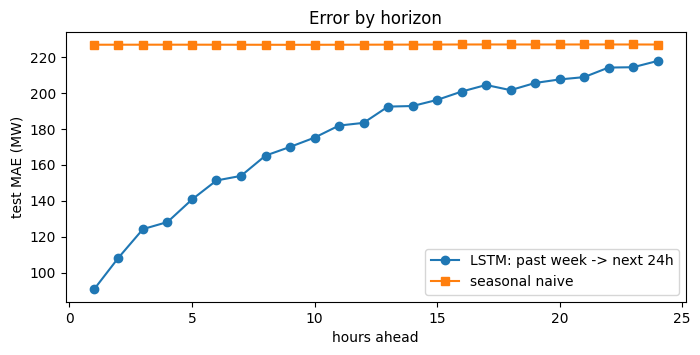

model, averaged over 24 horizons: 176.2 MW   | seasonal naive: 226.9 MW


In [7]:
pred_s = sc_y.inverse_transform(step.predict(Xs_te, verbose=0)); true_s = sc_y.inverse_transform(ys_te)
mae_by_h = np.abs(pred_s - true_s).mean(axis=0)

dem = test["Demand"].values     # seasonal-naive at every horizon: same hour yesterday
naive_by_h = np.array([mean_absolute_error(dem[n_in+h:len(dem)-n_out+h+1], dem[n_in+h-24:len(dem)-n_out+h+1-24]) for h in range(n_out)])

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 25), mae_by_h, marker="o", label="LSTM: past week -> next 24h")
plt.plot(range(1, 25), naive_by_h, marker="s", label="seasonal naive")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)"); plt.title("Error by horizon"); plt.legend(); plt.show()
print(f"model, averaged over 24 horizons: {mae_by_h.mean():.1f} MW   | seasonal naive: {naive_by_h.mean():.1f} MW")

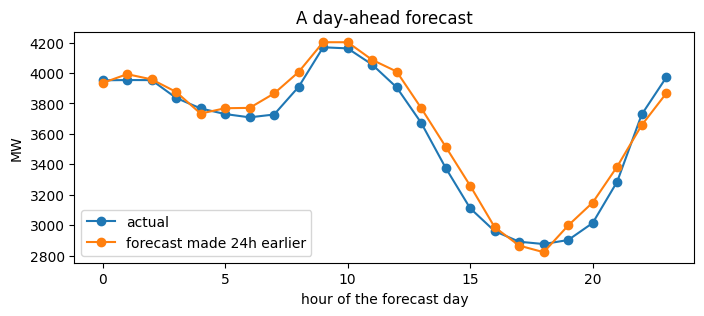

In [8]:
d = 200
plt.figure(figsize=(8, 3)); plt.plot(true_s[d], marker="o", label="actual"); plt.plot(pred_s[d], marker="o", label="forecast made 24h earlier")
plt.xlabel("hour of the forecast day"); plt.ylabel("MW"); plt.title("A day-ahead forecast"); plt.legend(); plt.show()

## Save the model and use it again

In [9]:
step.save('E4_Many_To_Many_Demand_dayahead.keras')
reloaded = load_model('E4_Many_To_Many_Demand_dayahead.keras')
print("reloaded model reproduces the forecast:", np.allclose(step.predict(Xs_te[:5], verbose=0), reloaded.predict(Xs_te[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Add a **holiday flag** column - the model has never been told July 4th isn't a Tuesday.
- Swap `LSTM` for `GRU` in the day-ahead model. Fewer parameters; same error?
- Train on 2011-2019 and test on **2020**. That's what distribution shift does to a forecast.